In [1]:
import pyodbc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

cnxn = pyodbc.connect('DSN=Hermes_DSN',autocommit=True)
cursor = cnxn.cursor()

In [2]:
isin = pd.read_excel('Data\\EA_ISINs.xlsx')

In [3]:
unique_isin = tuple(isin['ISIN'])

In [4]:
treasury = pd.read_csv('Data\\TreasuryCUSIP.csv')

In [5]:
unique_treasury = tuple(treasury['ISIN'].unique())

In [6]:
hedge_funds = pd.read_csv('key dataframe\\overlap_hedge_funds.csv')

In [7]:
hf_overlap = tuple(hedge_funds['entity_id'].unique())

# SFTDS dataset

## breakdown of individual parts

### only cayman 

In [ ]:
# data prep
query = f"""

SELECT 
    s.business_date,
    s.borrower_id AS entity_id,
    s.security_isin,
    SUM(s.nominal_value) AS borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND borrower_country_residence = 'KY'
    AND s_borrower.sector = 'IF'
    AND (
        (s.security_isin IN {unique_isin} AND s.nominal_ccy = 'EUR')
        OR (s.security_isin IN {unique_treasury} AND s.nominal_ccy = 'USD')
    )
GROUP BY s.business_date, s.borrower_id, s.security_isin
ORDER BY s.business_date, s.borrower_id, s.security_isin

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21784\1412984487.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [39]:
# Data prep
query = f"""

SELECT 
    s.business_date,
    s.lender_id AS entity_id,
    s.security_isin,
    SUM(s.nominal_value) AS lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND lender_country_residence = 'KY'
    AND s_lender.sector = 'IF'
    AND (
        (s.security_isin IN {unique_isin} AND s.nominal_ccy = 'EUR')
        OR (s.security_isin IN {unique_treasury} AND s.nominal_ccy = 'USD')
    )
GROUP BY s.business_date, s.lender_id, s.security_isin
ORDER BY s.business_date, s.lender_id, s.security_isin
"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21784\2129149566.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [40]:
df = df_borrowing.merge(df_lending, on= ['business_date', 'entity_id', 'security_isin'], how = 'outer')

In [41]:
len(df['entity_id'].unique())

263

### ever cayman and not just IF

In [42]:
# Data prep
query = f"""

WITH ky_bm_borrowers AS (
    SELECT DISTINCT borrower_id
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE borrower_country_residence IN ('KY')
)
SELECT 
    s.business_date,
    s.borrower_id AS entity_id,
    s.security_isin,
    SUM(s.nominal_value) AS borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND (
        s.borrower_id IN (SELECT borrower_id FROM ky_bm_borrowers)
    )
    AND (
        (s.security_isin IN {unique_isin} AND s.nominal_ccy = 'EUR')
        OR (s.security_isin IN {unique_treasury} AND s.nominal_ccy = 'USD')
    )
GROUP BY s.business_date, s.borrower_id, s.security_isin
ORDER BY s.business_date, s.borrower_id, s.security_isin

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21784\1254904652.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [43]:
# Data prep
query = f"""

WITH ky_bm_lenders AS (
    SELECT DISTINCT lender_id
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE lender_country_residence IN ('KY')
)
SELECT 
    s.business_date,
    s.lender_id AS entity_id,
    s.security_isin,
    SUM(s.nominal_value) AS lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND (
        s.lender_id IN (SELECT lender_id FROM ky_bm_lenders)
    )
    AND (
        (s.security_isin IN {unique_isin} AND s.nominal_ccy = 'EUR')
        OR (s.security_isin IN {unique_treasury} AND s.nominal_ccy = 'USD')
    )
GROUP BY s.business_date, s.lender_id, s.security_isin
ORDER BY s.business_date, s.lender_id, s.security_isin
"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21784\3269235713.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [44]:
df = df_borrowing.merge(df_lending, on= ['business_date', 'entity_id', 'security_isin'], how = 'outer')

In [45]:
len(df['entity_id'].unique())

449

In [ ]:
# 186 extra funds
449-263

186

### Bermuda

In [47]:
# Data prep
query = f"""

WITH ky_bm_borrowers AS (
    SELECT DISTINCT borrower_id
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE borrower_country_residence IN ('BM')
)
SELECT 
    s.business_date,
    s.borrower_id AS entity_id,
    s.security_isin,
    SUM(s.nominal_value) AS borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND (
        s.borrower_id IN (SELECT borrower_id FROM ky_bm_borrowers)
    )
    AND (
        (s.security_isin IN {unique_isin} AND s.nominal_ccy = 'EUR')
        OR (s.security_isin IN {unique_treasury} AND s.nominal_ccy = 'USD')
    )
GROUP BY s.business_date, s.borrower_id, s.security_isin
ORDER BY s.business_date, s.borrower_id, s.security_isin

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21784\730758032.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [48]:
# Data prep
query = f"""

WITH ky_bm_lenders AS (
    SELECT DISTINCT lender_id
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE lender_country_residence IN ('BM')
)
SELECT 
    s.business_date,
    s.lender_id AS entity_id,
    s.security_isin,
    SUM(s.nominal_value) AS lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND (
        s.lender_id IN (SELECT lender_id FROM ky_bm_lenders)
    )
    AND (
        (s.security_isin IN {unique_isin} AND s.nominal_ccy = 'EUR')
        OR (s.security_isin IN {unique_treasury} AND s.nominal_ccy = 'USD')
    )
GROUP BY s.business_date, s.lender_id, s.security_isin
ORDER BY s.business_date, s.lender_id, s.security_isin
"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21784\1248724639.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [49]:
df = df_borrowing.merge(df_lending, on= ['business_date', 'entity_id', 'security_isin'], how = 'outer')

In [50]:
len(df['entity_id'].unique())

67

### including hedged strategy

In [56]:
# Data prep
query = f"""

WITH ky_bm_borrowers AS (
    SELECT DISTINCT borrower_id
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE borrower_country_residence IN ('KY', 'BM')
)
SELECT 
    s.business_date,
    s.borrower_id AS entity_id,
    s.security_isin,
    SUM(s.nominal_value) AS borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND (
        s.borrower_id IN (SELECT borrower_id FROM ky_bm_borrowers)
        OR s_borrower.if_strategy = 'Hedge'
    )
    AND (
        (s.security_isin IN {unique_isin} AND s.nominal_ccy = 'EUR')
        OR (s.security_isin IN {unique_treasury} AND s.nominal_ccy = 'USD')
    )
GROUP BY s.business_date, s.borrower_id, s.security_isin
ORDER BY s.business_date, s.borrower_id, s.security_isin

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21784\3379403016.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [57]:
# Data prep
query = f"""

WITH ky_bm_lenders AS (
    SELECT DISTINCT lender_id
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE lender_country_residence IN ('KY', 'BM')
)
SELECT 
    s.business_date,
    s.lender_id AS entity_id,
    s.security_isin,
    SUM(s.nominal_value) AS lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND (
        s.lender_id IN (SELECT lender_id FROM ky_bm_lenders)
        OR s_lender.if_strategy = 'Hedge'
    )
    AND (
        (s.security_isin IN {unique_isin} AND s.nominal_ccy = 'EUR')
        OR (s.security_isin IN {unique_treasury} AND s.nominal_ccy = 'USD')
    )
GROUP BY s.business_date, s.lender_id, s.security_isin
ORDER BY s.business_date, s.lender_id, s.security_isin
"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21784\2356516322.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [58]:
df = df_borrowing.merge(df_lending, on= ['business_date', 'entity_id', 'security_isin'], how = 'outer')

In [59]:
len(df['entity_id'].unique())

568

## final - including whatever identified in overlap analysis

In [32]:
# Data prep
query = f"""

WITH ky_bm_borrowers AS (
    SELECT DISTINCT borrower_id
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE borrower_country_residence IN ('KY', 'BM')
)
SELECT 
    s.business_date,
    s.borrower_id AS entity_id,
    MAX(CASE WHEN s_borrower.sector = 'BANK' THEN 1 ELSE 0 END) AS bank_indicator,
    s.security_isin,
    SUM(s.nominal_value) AS borrowing_volume,
    AVG(repo_rate) as borrowing_rate, AVG(CASE WHEN contractual_maturity < 1 THEN 1 ELSE contractual_maturity END) as borrowing_term
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.gnlcoll = 'SPEC'
    AND (
        s.borrower_id IN (SELECT borrower_id FROM ky_bm_borrowers)
        OR s_borrower.if_strategy = 'Hedge'
        OR borrower_id IN {hf_overlap}
        OR (s_borrower.sector = 'BANK' AND borrower_country = 'GB') 
    )
    AND (
        (s.security_isin IN {unique_isin} AND s.nominal_ccy = 'EUR')
        OR (s.security_isin IN {unique_treasury} AND s.nominal_ccy = 'USD')
    )
GROUP BY s.business_date, s.borrower_id, s.security_isin
ORDER BY s.business_date, s.borrower_id, s.security_isin

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_28036\3800983919.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [33]:
# Data prep
query = f"""

WITH ky_bm_lenders AS (
    SELECT DISTINCT lender_id
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
    WHERE lender_country_residence IN ('KY', 'BM')
)
SELECT 
    s.business_date,
    s.lender_id AS entity_id,
    MAX(CASE WHEN s_lender.sector = 'BANK' THEN 1 ELSE 0 END) AS bank_indicator,
    s.security_isin,
    SUM(s.nominal_value) AS lending_volume,
    AVG(repo_rate) as lending_rate, AVG(CASE WHEN contractual_maturity < 1 THEN 1 ELSE contractual_maturity END) as lending_term
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.gnlcoll = 'SPEC'
    AND (
        s.lender_id IN (SELECT lender_id FROM ky_bm_lenders)
        OR s_lender.if_strategy = 'Hedge'
        OR s.lender_id IN {hf_overlap}
        OR (s_lender.sector = 'BANK' AND lender_country = 'GB')
    )
    AND (
        (s.security_isin IN {unique_isin} AND s.nominal_ccy = 'EUR')
        OR (s.security_isin IN {unique_treasury} AND s.nominal_ccy = 'USD')
    )
GROUP BY s.business_date, s.lender_id, s.security_isin
ORDER BY s.business_date, s.lender_id, s.security_isin
"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_28036\612648164.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [34]:
df = df_borrowing.merge(df_lending, on= ['business_date', 'entity_id', 'bank_indicator', 'security_isin'], how = 'outer')

In [35]:
len(df['entity_id'].unique())

638

In [36]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [37]:
df['borrowing_volume'].fillna(0,inplace=True)
df['lending_volume'].fillna(0,inplace=True)

In [38]:
#pd.DataFrame(df['entity_id'].unique()).to_csv('sftds_hedgefunds.csv')

In [39]:
df.to_csv('key dataframe\\sftds_dataframe.csv')

In [ ]:
# AFTER THIS, IS OLD!

## adding on the run

In [16]:
df_otr = pd.read_csv('Data\\otrnumber.csv')

In [17]:
cusip_translator = pd.read_csv('Data\\TreasuryCUSIP.csv')

In [18]:
df_otr = df_otr.merge(cusip_translator, left_on = 'cusip', right_on = 'CUSIP', how = 'left')

In [19]:
df_otr['date'] = pd.to_datetime(df_otr['date'], dayfirst=True)
df['business_date'] = pd.to_datetime(df['business_date'], format='%Y-%m-%d')

In [20]:
df.columns

Index(['business_date', 'entity_id', 'security_isin', 'borrowing_volume',
       'borrowing_rate', 'borrowing_term', 'lending_volume', 'lending_rate',
       'lending_term'],
      dtype='object')

In [21]:
df = df.merge(df_otr[['date', 'otr_maturity', 'otr_type', 'issuedate', 'otrnumber', 'ISIN']], left_on=['business_date', 'security_isin'], right_on=['date', 'ISIN'], how = 'left')

In [22]:
df = df[['business_date', 'entity_id', 'security_isin', 'borrowing_volume',
       'borrowing_rate', 'borrowing_term', 'lending_volume', 'lending_rate',
       'lending_term', 'otr_maturity', 'otr_type', 'issuedate',
       'otrnumber']]

## Adding deliverable futures

In [23]:
import pandas as pd
import numpy as np

# --- 1. Load reference files ---
df_del = pd.read_excel('Data\\Deliverables_EU.xlsx')
df_isin_cusip = pd.read_excel('Data\\EA_ISIN_TO_CUSIPS.xlsx')

In [24]:
# --- 2. CUSIP8 -> ISIN mapping ---
df_isin_cusip['CUSIP8'] = df_isin_cusip['CUSIP'].str[:8]
cusip_to_isin = df_isin_cusip.set_index('CUSIP8')['ISIN'].to_dict()

In [25]:
# --- 3. Parse contract tickers ---
ticker_to_category = {
    'RX': 'bund', 'OE': 'bobl', 'DU': 'schatz',
    'IK': 'btp', 'OAT': 'oat', 'BTS': 'short_btp', 'UB': 'buxl'
}
month_map = {'H': '03', 'M': '06', 'U': '09', 'Z': '12'}

def contract_to_category(contract):
    for prefix, cat in sorted(ticker_to_category.items(), key=lambda x: -len(x[0])):
        if contract.startswith(prefix):
            rest = contract[len(prefix):]
            month_code = rest[0]
            year = rest[1:]
            month = month_map.get(month_code)
            return f"{cat}_{month}_{year}"
    return None

df_del['futures_contract'] = df_del['Contract'].apply(contract_to_category)

In [26]:
# --- 4. Last trading dates (format is yyyy-dd-mm) ---
last_trading_raw = [
    '2021-08-03', '2021-08-06', '2021-08-09', '2021-08-12',
    '2022-08-03', '2022-08-06', '2022-08-09', '2022-08-12',
    '2023-08-03', '2023-08-06', '2023-07-09', '2023-07-12',
    '2024-07-03', '2024-06-06', '2024-06-09', '2024-06-12',
    '2025-06-03', '2025-06-06', '2025-08-09', '2025-08-12',
    '2026-06-03', '2026-08-06', '2026-08-09'
]
# Parse as yyyy-dd-mm
last_trading_dates = pd.to_datetime(last_trading_raw, format='%Y-%d-%m')

# Map each (month, year) to its last trading date
# month_year key like "03_21" -> last trading date
ltd_map = {}
for dt in last_trading_dates:
    month = f"{dt.month:02d}"
    year = f"{dt.year % 100:02d}"  # 2-digit year
    key = f"{month}_{year}"
    ltd_map[key] = dt

In [27]:
# --- 5. Melt deliverables to long format ---
deliv_cols = [c for c in df_del.columns if c.startswith('Deliverable')]
df_long = df_del.melt(id_vars=['futures_contract'], value_vars=deliv_cols, value_name='CUSIP8')
df_long = df_long.dropna(subset=['CUSIP8'])[['futures_contract', 'CUSIP8']]
df_long['security_isin'] = df_long['CUSIP8'].map(cusip_to_isin)
df_long = df_long.dropna(subset=['security_isin'])[['futures_contract', 'security_isin']]
df_long = df_long.drop_duplicates()

# Extract future_base and month_year for each contract
df_long['future_base'] = df_long['futures_contract'].apply(lambda x: x.rsplit('_', 2)[0])
df_long['month_year'] = df_long['futures_contract'].apply(lambda x: '_'.join(x.rsplit('_', 2)[1:]))
df_long['last_trading_date'] = df_long['month_year'].map(ltd_map)

In [28]:
# --- US ticker mapping ---
us_ticker_to_category = {
    'UXY': 'ultra10', 'WN': 'ultrabond', 'TY': 'tn10',
    'FV': 'tn5', 'TU': 'tn2', 'US': 'tbond'
}

# Combined mapping
all_ticker_to_category = {**ticker_to_category, **us_ticker_to_category}

def contract_to_category(contract):
    for prefix, cat in sorted(all_ticker_to_category.items(), key=lambda x: -len(x[0])):
        if contract.startswith(prefix):
            rest = contract[len(prefix):]
            month_code = rest[0]
            year = rest[1:]
            month = month_map.get(month_code)
            return f"{cat}_{month}_{year}"
    return None

# --- Load US deliverables (long format: Contract, CUSIP) ---
df_del_us = pd.read_csv('Data\\Deliverables_US.csv')
df_del_us['futures_contract'] = df_del_us['Contract'].apply(contract_to_category)

# --- Load US CUSIP-to-ISIN mapping ---
df_us_cusip = pd.read_csv('Data\\TreasuryCUSIP.csv')
us_cusip_to_isin = df_us_cusip.set_index('CUSIP')['ISIN'].to_dict()

# --- Map CUSIP -> ISIN ---
df_long_us = df_del_us[['futures_contract', 'CUSIP']].copy()
df_long_us['security_isin'] = df_long_us['CUSIP'].map(us_cusip_to_isin)
df_long_us = df_long_us.dropna(subset=['security_isin'])[['futures_contract', 'security_isin']]
df_long_us = df_long_us.drop_duplicates()

# --- Compute US last trading dates ---
from pandas.tseries.offsets import BMonthEnd, BDay

def us_last_trading_date(month, year):
    dt = pd.Timestamp(year=year, month=month, day=1) + BMonthEnd(1)
    return dt - BDay(7)

us_ltd_map = {}
for m in [3, 6, 9, 12]:
    for y in range(2018, 2027):
        key = f"{m:02d}_{y % 100:02d}"
        us_ltd_map[key] = us_last_trading_date(m, y)

# --- Add last trading date (using US map, not EU) ---
df_long_us['month_year'] = df_long_us['futures_contract'].apply(lambda x: '_'.join(x.rsplit('_', 2)[1:]))
df_long_us['last_trading_date'] = df_long_us['month_year'].map(us_ltd_map)

# --- Concatenate with EU long deliverables ---
df_long = pd.concat([df_long, df_long_us], ignore_index=True)

In [29]:
# --- 6. Merge-based approach (fast & clean) ---
df['business_date'] = pd.to_datetime(df['business_date'])
df['_idx'] = range(len(df))

# Merge: each row in df fans out to all contracts the bond is deliverable into
merged = df[['_idx', 'security_isin', 'business_date']].merge(
    df_long[['security_isin', 'futures_contract', 'last_trading_date']],
    on='security_isin', how='inner'
)

# Filter to contracts not yet expired
merged = merged[merged['last_trading_date'] >= merged['business_date']]

# Extract product category (e.g. 'tn10', 'ultra10', 'bund')
merged['product'] = merged['futures_contract'].apply(lambda x: x.rsplit('_', 2)[0])

# For each (row, product), keep only the nearest expiry
merged = merged.sort_values(['_idx', 'product', 'last_trading_date'])
merged = merged.groupby(['_idx', 'product']).first().reset_index()

# Identify future_1 (nearest contract overall per row)
future_1 = merged.sort_values(['_idx', 'last_trading_date']).groupby('_idx').first().reset_index()
future_1 = future_1[['_idx', 'futures_contract', 'last_trading_date']].rename(
    columns={'futures_contract': 'future_1', 'last_trading_date': 'ltd_1'}
)

# For future_2: keep only contracts sharing the same expiry as future_1 but different product
merged2 = merged.merge(future_1, on='_idx')
merged2 = merged2[
    (merged2['last_trading_date'] == merged2['ltd_1']) &
    (merged2['futures_contract'] != merged2['future_1'])
]
future_2 = merged2.sort_values(['_idx', 'last_trading_date']).groupby('_idx').first().reset_index()
future_2 = future_2[['_idx', 'futures_contract']].rename(columns={'futures_contract': 'future_2'})

# Join back
df = df.merge(future_1[['_idx', 'future_1']], on='_idx', how='left')
df = df.merge(future_2, on='_idx', how='left')
df = df.drop(columns='_idx')

In [30]:
df[df['future_2'] == 'ultra10_03_21'].head()

,business_date,entity_id,security_isin,borrowing_volume,borrowing_rate,borrowing_term,lending_volume,lending_rate,lending_term,otr_maturity,otr_type,issuedate,otrnumber,future_1,future_2
743,2021-01-04,0XXENSNEYD5BSB49GB59,US91282CAE12,4.843750e+06,0.1200,18.0,0.0,NaN,NaN,10.0,2.0,15/08/2020,2.0,tn10_03_21,ultra10_03_21
744,2021-01-04,0XXENSNEYD5BSB49GB59,US91282CAV37,7.272625e+07,-0.0007,30.0,0.0,NaN,NaN,10.0,2.0,15/11/2020,1.0,tn10_03_21,ultra10_03_21
827,2021-01-04,2CNR4I7RPCUNYMQ52H12,US91282CAE12,2.133780e+08,0.0100,15.0,0.0,NaN,NaN,10.0,2.0,15/08/2020,2.0,tn10_03_21,ultra10_03_21
830,2021-01-04,2CNR4I7RPCUNYMQ52H12,US91282CAV37,2.481250e+08,-0.0300,9.0,0.0,NaN,NaN,10.0,2.0,15/11/2020,1.0,tn10_03_21,ultra10_03_21
864,2021-01-04,4ELHTRKXHK6ELH9WOI24,US91282CAE12,5.453000e+06,0.1500,5.0,0.0,NaN,NaN,10.0,2.0,15/08/2020,2.0,tn10_03_21,ultra10_03_21


## Adding CTD info

In [64]:
import pandas as pd
import numpy as np

# --- 1. Parse EUBASIS.xlsx into long format ---
df_raw = pd.read_excel('Data\\EUBASIS.xlsx', header=None)

In [65]:
products = [
    (1, 'RX1'), (6, 'RX2'), (11, 'OE1'), (16, 'OE2'),
    (21, 'DU1'), (26, 'DU2'), (31, 'IK1'), (36, 'IK2'),
    (41, 'OAT1'), (46, 'OAT2'), (51, 'UB1'), (56, 'UB2'),
    (61, 'BTS1'), (66, 'BTS2')
]

data = df_raw.iloc[3:].copy()
data[0] = pd.to_datetime(data[0])

frames = []
for start_col, label in products:
    block = data[[0, start_col, start_col+1, start_col+2, start_col+3, start_col+4]].copy()
    block.columns = ['date', 'implied_repo', 'open_interest', 'ctd_net_basis', 'ticker', 'ctd_cusip']
    frames.append(block)

df_basis = pd.concat(frames, ignore_index=True)

In [66]:
# --- 2. Convert Bloomberg ticker to futures_contract format ---
ticker_to_category = {
    'RX': 'bund', 'OE': 'bobl', 'DU': 'schatz',
    'IK': 'btp', 'OAT': 'oat', 'BTS': 'short_btp', 'UB': 'buxl'
}
month_map = {'H': '03', 'M': '06', 'U': '09', 'Z': '12'}

def ticker_to_fc(ticker):
    if pd.isna(ticker):
        return None
    for prefix, cat in sorted(ticker_to_category.items(), key=lambda x: -len(x[0])):
        if ticker.startswith(prefix):
            rest = ticker[len(prefix):]
            return f"{cat}_{month_map.get(rest[0])}_{rest[1:]}"
    return None

df_basis['futures_contract'] = df_basis['ticker'].apply(ticker_to_fc)

In [67]:
# --- 3. Convert CTD CUSIP to ISIN for CTD identity matching ---
df_isin_cusip = pd.read_excel('Data\\EA_ISIN_TO_CUSIPS.xlsx')
df_isin_cusip['CUSIP8'] = df_isin_cusip['CUSIP'].str[:8]
cusip_to_isin = df_isin_cusip.set_index('CUSIP8')['ISIN'].to_dict()
df_basis['ctd_isin'] = df_basis['ctd_cusip'].map(cusip_to_isin)

In [68]:
# --- 4. Prepare basis lookup: keep only what we need ---
basis_cols = ['date', 'futures_contract', 'implied_repo', 'open_interest', 'ctd_net_basis', 'ctd_isin']
df_basis = df_basis[basis_cols].dropna(subset=['futures_contract'])

In [69]:
# --- Parse USBASIS.csv into long format ---
df_us_raw = pd.read_csv('Data\\USBASIS.csv')
df_us_raw['Date'] = pd.to_datetime(df_us_raw['Date'], format='%m/%d/%Y')

us_products = ['TY1', 'TY2', 'FV1', 'FV2', 'TU1', 'TU2',
               'UXY1', 'UXY2', 'WN1', 'WN2', 'US1', 'US2']

us_ticker_to_category = {
    'UXY': 'ultra10', 'WN': 'ultrabond', 'TY': 'tn10',
    'FV': 'tn5', 'TU': 'tn2', 'US': 'tbond'
}

def ticker_to_fc_us(ticker):
    if pd.isna(ticker):
        return None
    for prefix, cat in sorted(us_ticker_to_category.items(), key=lambda x: -len(x[0])):
        if ticker.startswith(prefix):
            rest = ticker[len(prefix):]
            return f"{cat}_{month_map.get(rest[0])}_{rest[1:]}"
    return None

us_frames = []
for prod in us_products:
    block = df_us_raw[['Date',
                        f'{prod}_FUT_IMPLIED_REPO_RT',
                        f'{prod}_OPEN_INT',
                        f'{prod}_FUT_CTD_NET_BASIS',
                        f'{prod}_FUT_CUR_GEN_TICKER',
                        f'{prod}_FUT_CTD_CUSIP']].copy()
    block.columns = ['date', 'implied_repo', 'open_interest', 'ctd_net_basis', 'ticker', 'ctd_cusip']
    us_frames.append(block)

df_basis_us = pd.concat(us_frames, ignore_index=True)
df_basis_us['futures_contract'] = df_basis_us['ticker'].apply(ticker_to_fc_us)

# --- Map US CTD CUSIP to ISIN ---
df_us_cusip = pd.read_csv('Data\\TreasuryCUSIP.csv')
us_cusip_to_isin = df_us_cusip.set_index('CUSIP')['ISIN'].to_dict()
df_basis_us['ctd_isin'] = df_basis_us['ctd_cusip'].map(us_cusip_to_isin)

# --- Keep only needed columns ---
df_basis_us = df_basis_us[['date', 'futures_contract', 'implied_repo', 'open_interest', 'ctd_net_basis', 'ctd_isin']]
df_basis_us = df_basis_us.dropna(subset=['futures_contract'])

# --- Combine EU and US basis data ---
df_basis = pd.concat([df_basis, df_basis_us], ignore_index=True)

In [70]:
# --- 5. Merge for future_1 ---
df = df.merge(
    df_basis.rename(columns={
        'implied_repo': 'ctd_implied_repo_1',
        'open_interest': 'ctd_open_interest_1',
        'ctd_net_basis': 'ctd_net_basis_1',
        'ctd_isin': 'ctd_isin_1'
    }),
    left_on=['business_date', 'future_1'],
    right_on=['date', 'futures_contract'],
    how='left'
).drop(columns=['date', 'futures_contract'])

# CTD identity: is this bond the CTD for future_1?
df['ctd_identity_1'] = (df['security_isin'] == df['ctd_isin_1']).astype(int)
df.loc[df['ctd_isin_1'].isna(), 'ctd_identity_1'] = np.nan
df = df.drop(columns=['ctd_isin_1'])

# --- 6. Merge for future_2 ---
df = df.merge(
    df_basis.rename(columns={
        'implied_repo': 'ctd_implied_repo_2',
        'open_interest': 'ctd_open_interest_2',
        'ctd_net_basis': 'ctd_net_basis_2',
        'ctd_isin': 'ctd_isin_2'
    }),
    left_on=['business_date', 'future_2'],
    right_on=['date', 'futures_contract'],
    how='left'
).drop(columns=['date', 'futures_contract'])

# CTD identity: is this bond the CTD for future_2?
df['ctd_identity_2'] = (df['security_isin'] == df['ctd_isin_2']).astype(int)
df.loc[df['ctd_isin_2'].isna(), 'ctd_identity_2'] = np.nan
df = df.drop(columns=['ctd_isin_2'])

In [71]:
df[df['ctd_identity_1'].isna() == False].sample(5)

,business_date,entity_id,security_isin,borrowing_volume,borrowing_rate,borrowing_term,lending_volume,lending_rate,lending_term,otr_maturity,...,future_1,future_2,ctd_implied_repo_1,ctd_open_interest_1,ctd_net_basis_1,ctd_identity_1,ctd_implied_repo_2,ctd_open_interest_2,ctd_net_basis_2,ctd_identity_2
4408309,2022-11-21,TWY0GIZ67OP1ZDMFR832,US91282CCS89,0.0,NaN,NaN,3.701338e+07,2.95,NaN,10.0,...,tn10_12_22,NaN,3.13649,3365253,2.6344,0.0,NaN,NaN,NaN,NaN
4753346,2023-06-08,549300OR6B15UIZ9FZ95,DE0001102432,0.0,NaN,NaN,1.178436e+08,2.92,8.0,NaN,...,buxl_06_23,NaN,6.99641,6680,-0.0249,1.0,NaN,NaN,NaN,NaN
5052517,2023-10-31,WHLAIMQOU4GJKYFZHC97,IT0005544082,0.0,NaN,NaN,6.411250e+07,3.93,10.0,NaN,...,btp_12_23,NaN,3.93316,364532,-0.0049,1.0,NaN,NaN,NaN,NaN
2752419,2024-11-26,DBMPQSXT0LEURZ0IGP72,FR001400L834,255459289.8,3.24,7.666667,4.200515e+07,3.19,9.0,NaN,...,oat_12_24,NaN,3.11235,436856,0.0018,1.0,NaN,NaN,NaN,NaN
1301068,2023-03-13,549300KM4DRKLEPZUO76,US91282CGJ45,160198875.0,4.61,1.000000,0.000000e+00,NaN,NaN,7.0,...,tn10_03_23,NaN,3.0355,5232,2.5088,0.0,NaN,NaN,NaN,NaN


In [72]:
# Get current columns
cols = df.columns.tolist()

# Remove future_1 and future_2 from their current positions
cols.remove('future_1')
cols.remove('future_2')

# Find where to insert (right after security_isin)
idx = cols.index('security_isin') + 1

# Insert them
cols.insert(idx, 'future_1')
cols.insert(idx + 1, 'future_2')

df = df[cols]

In [ ]:
#df_sftds = pd.read_csv('sftds_dataframe.csv', index_col = 0)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_4880\2336348389.py:1: DtypeWarning: Columns (4,5,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sftds = pd.read_csv('sftds_dataframe.csv', index_col = 0)


In [31]:
us_prefix_map = {
    'TY': 'tn10',
    'FV': 'tn5',
    'TU': 'tn2',
    'UXY': 'ultra10',
    'WN': 'ultrabond',
    'US': 'tbond',
}
eur_prefix_map = {
    'RX': 'bund', 'OE': 'bobl', 'DU': 'schatz',
    'IK': 'btp', 'OAT': 'oat', 'UB': 'buxl', 'BTS': 'short_btp',
}

In [32]:
df_sftds = df

In [33]:
# Invert the maps to go from suffix -> bloomberg prefix
us_inv = {v: k for k, v in us_prefix_map.items()}
eur_inv = {v: k for k, v in eur_prefix_map.items()}
prefix_map = {**us_inv, **eur_inv}
month_map = {'H': '03', 'M': '06', 'U': '09', 'Z': '12'}

month_to_letter = {v: k for k, v in month_map.items()}

def to_bloomberg(fc):
    parts = fc.split('_')
    if len(parts) < 3:
        return None
    name = '_'.join(parts[:-2])
    month = parts[-2]
    year = parts[-1]
    prefix = prefix_map.get(name)
    month_letter = month_to_letter.get(month)
    if prefix is None or month_letter is None:
        return None
    return prefix + month_letter + year

df_sftds['futures_identifier1'] = df_sftds['future_1'][df_sftds['future_1'].isna() == False].apply(to_bloomberg)
df_sftds['futures_identifier2'] = df_sftds['future_2'][df_sftds['future_2'].isna() == False].apply(to_bloomberg)

In [34]:
df_sftds = df_sftds[['business_date', 'entity_id', 'security_isin', 'futures_identifier1', 'futures_identifier2', 'future_1', 'future_2',
       'borrowing_volume', 'borrowing_rate', 'borrowing_term',
       'lending_volume', 'lending_rate', 'lending_term', 'otr_maturity',
       'otr_type', 'issuedate', 'otrnumber']]

In [35]:
df_sftds[df_sftds['future_2'].isna() == False].head()

,business_date,entity_id,security_isin,futures_identifier1,futures_identifier2,future_1,future_2,borrowing_volume,borrowing_rate,borrowing_term,lending_volume,lending_rate,lending_term,otr_maturity,otr_type,issuedate,otrnumber
743,2021-01-04,0XXENSNEYD5BSB49GB59,US91282CAE12,TYH21,UXYH21,tn10_03_21,ultra10_03_21,4.843750e+06,0.1200,18.0,0.0,NaN,NaN,10.0,2.0,15/08/2020,2.0
744,2021-01-04,0XXENSNEYD5BSB49GB59,US91282CAV37,TYH21,UXYH21,tn10_03_21,ultra10_03_21,7.272625e+07,-0.0007,30.0,0.0,NaN,NaN,10.0,2.0,15/11/2020,1.0
827,2021-01-04,2CNR4I7RPCUNYMQ52H12,US91282CAE12,TYH21,UXYH21,tn10_03_21,ultra10_03_21,2.133780e+08,0.0100,15.0,0.0,NaN,NaN,10.0,2.0,15/08/2020,2.0
830,2021-01-04,2CNR4I7RPCUNYMQ52H12,US91282CAV37,TYH21,UXYH21,tn10_03_21,ultra10_03_21,2.481250e+08,-0.0300,9.0,0.0,NaN,NaN,10.0,2.0,15/11/2020,1.0
864,2021-01-04,4ELHTRKXHK6ELH9WOI24,US91282CAE12,TYH21,UXYH21,tn10_03_21,ultra10_03_21,5.453000e+06,0.1500,5.0,0.0,NaN,NaN,10.0,2.0,15/08/2020,2.0


In [ ]:
#df_sftds.to_csv('key dataframe\\sftds_dataframe.csv')

In [ ]:
#df = pd.read_csv('key dataframe\\sftds_dataframe.csv', index_col=0)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21528\744256465.py:1: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('key dataframe\\sftds_dataframe.csv', index_col=0)


In [3]:
df.columns

Index(['business_date', 'entity_id', 'security_isin', 'futures_identifier1',
       'futures_identifier2', 'future_1', 'future_2', 'borrowing_volume',
       'borrowing_rate', 'borrowing_term', 'lending_volume', 'lending_rate',
       'lending_term'],
      dtype='object')

In [4]:
df = df[['business_date', 'entity_id', 'security_isin', 'borrowing_volume',
       'borrowing_rate', 'borrowing_term', 'lending_volume', 'lending_rate',
       'lending_term']]

In [ ]:
#df.to_csv('key dataframe\\sftds_dataframe.csv')

In [ ]:
df.head()

# EMIR dataset

In [8]:
# Data prep
query = f"""

SELECT reference_period as business_date, notional_leg1_currency as currency, other_cpty_id as entity_id, MAX(CASE WHEN s_entity.sector = 'BANK' THEN 1 ELSE 0 END) AS bank_indicator,
 product_isin, underlying_id, underlying_maturity_date, underlying_index_name, maturity_date, CASE WHEN direction = 'MAKE' THEN 'SLLR' WHEN direction = 'TAKE' THEN 'BYER' ELSE direction END AS direction, SUM(notional_leg1) as vol
FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2024-04-29'
AND reference_period <= '2025-12-31'
AND notional_leg1 < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional_leg1 > 0
AND notional_leg1_currency IN ("EUR", "USD")
AND LEFT(product_cfi, 3) = 'FFD'
AND (LEFT(underlying_id, 2) != 'EU' OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (s_entity.sector = 'IF' OR other_cpty_id_esa_sector_riad = 'S124' OR other_cpty_id IN {hf_overlap} OR (s_entity.sector = 'BANK' AND other_cpty_id_country_code_gleif = 'GB'))
GROUP BY reference_period, currency, other_cpty_id, product_isin, underlying_id, underlying_maturity_date, underlying_index_name, maturity_date, direction
ORDER BY reference_period, currency, other_cpty_id, product_isin, underlying_id, underlying_maturity_date, underlying_index_name, maturity_date, direction

"""

df_emir_refit = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_18412\554069765.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_refit = pd.read_sql_query(query, cnxn)


In [9]:
# Data prep
query = f"""


SELECT reference_period as business_date, notional_currency1 as currency, other_cpty_id as entity_id, MAX(CASE WHEN s_entity.sector = 'BANK' THEN 1 ELSE 0 END) AS bank_indicator,
 product_id as product_isin, underlying_id, underlying_maturity_date, underlying_index_name, maturity_date, counterparty_side as direction, SUM(notional) as vol
FROM crp_emir_ecb.emir_ecb_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2021-01-04'
AND reference_period <= '2024-04-29'
AND notional < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional > 0
AND notional_currency1 IN ("EUR", "USD")
AND LEFT(product_clssfctn, 3) = 'FFD'
AND ((LEFT(underlying_id, 2) NOT IN ('EU', 'XC')) OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (s_entity.sector = 'IF' OR s_entity.sector = 'OFI' OR s_entity.sector = 'OTHR' OR other_cpty_id_esa_sector = 'S124' OR other_cpty_id IN {hf_overlap} OR (s_entity.sector = 'BANK' AND other_cpty_id_country_code = 'GB'))
GROUP BY reference_period, currency, other_cpty_id, product_isin, underlying_id, underlying_maturity_date, underlying_index_name, maturity_date, direction
ORDER BY reference_period, currency, other_cpty_id, product_isin, underlying_id, underlying_maturity_date, underlying_index_name, maturity_date, direction


"""

df_emir_old = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_18412\2265903117.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_old = pd.read_sql_query(query, cnxn)


In [10]:
df_emir = pd.concat([df_emir_refit, df_emir_old]).drop_duplicates().reset_index(drop=True)

## Underlying index Name

In [11]:
# Mapping from underlying_index_name to short futures name
name_to_future = {}

# --- EUR Bond Futures ---
schatz_names = [
    'EURX ESCHATZ', 'EURO SCHATZ', 'Euro Schatz', 'Euro Schatz-Future',
    'Euro-Schatz', 'EURO - SCHATZ', 'Euro Schatz -2 Year Bond',
    'Euro-Schatz-2-Year-Bond'
]
for n in schatz_names:
    name_to_future[n] = 'schatz'

bobl_names = [
    'EURX EURBOBL', 'EURO BOBL', 'Euro Bobl -5 Year Bond', 'Euro-Bobl',
    'Euro-Bobl Futures (FGBM)', 'Euro-Bobl Futures',
    'Euro-Bobl-5-Year-Bond', 'Euro-Bobl 5yr 6%'
]
for n in bobl_names:
    name_to_future[n] = 'bobl'

bund_names = [
    'EURO BUND', '"EURX EUR-BUND"', 'Euro Bund -10 Year Bond', 'Euro-Bund',
    'Euro-Bund Futures', 'Euro bund', 'Euro Bund', 'BUND', 'Euro Bund-Future',
    'FGBL', 'EURO BUND FUTURES', 'EURO EU BOND EUROPEAN LT UND',
    'BUND FUTURES SEP24', 'BUND FUTURES DEC24', 'BUND FUTURES MAR25',
    'BUND FUTURES JUN25', 'FGBL MAR25 [FIXED INCOME FUTURES',
    'FGBL SI 20250606 PS', 'FGBL SI 20250908 PS', 'FGBL SI 20251208 PS',
    'Euro-Bund-10-Year-Bond', 'Euro-Bund 10yr 6%'
]
for n in bund_names:
    name_to_future[n] = 'bund'

buxl_names = [
    '"EURX EURO-BUXL"', 'GERMAN GOVERNMENT BUXL  Bond',
    'Euro Buxl -15 - 30 Year Bond', 'Euro-Buxl Futures',
    'Euro Buxl Futures', 'Euro Buxl', 'Euro-Buxl',
    'Euro-Buxl-15-30-Year-Bond'
]
for n in buxl_names:
    name_to_future[n] = 'buxl'

btp_names = [
    'EURO-BTP LONGTERM ITA GOV BOND', 'Euro-BTP Italian Government Bond',
    'Euro BTP Futures', '"EUX EURO-BTP"', 'Long-Term Euro-BTP',
    'BTP FUTURES JUN24', 'BTP FUTURES SEP24', 'BTP FUTURES DEC24',
    'BTP FUTURES MAR25', 'BTP FUTURES JUN25', 'BTP FUTURES SEP25',
    'Euro-BTP-Italian-Government-Bond', 'Euro BTP Futures'
]
for n in btp_names:
    name_to_future[n] = 'btp'

short_btp_names = [
    'SHORT TERM EURO-BTP  bond', 'Short-Term Euro-BTP Italian Government Bond',
    'SHORT TERM BTP FUTURES', 'Short-Term Euro-BTP',
    'Short-Term-Euro-BTP-Italian-Government-Bond'
]
for n in short_btp_names:
    name_to_future[n] = 'short_btp'

oat_names = [
    'EURO-OAT bond', 'Euro-OAT French Government Bond', 'FOAT', 'EUX FOAT',
    'EURO-OAT FUTURES', 'Euro-OAT', 'Euro-OAT Futures',
    'Euro-OAT-French-Government-Bond'
]
for n in oat_names:
    name_to_future[n] = 'oat'

bono_names = [
    'EURO-BONO SPANISH GOV BOND',
    'Euro-BONO-Futures-on-Long-term-Spanish'
]
for n in bono_names:
    name_to_future[n] = 'bono'

# --- USD Bond Futures ---
tn2_names = [
    '"CBT 2Y T-NOTE"', '2YUSTN bond', '2 Year US Treasury Note',
    'CBT 2 Year Treasury Notes', 'CBOT 2-YEAR TREAS. NOTE', '2-Year T-Note',
    'CBOT-TWO-YEAR-TREASURY-NOTE-FUTURE', '2-Year T-Not',
    '2-Year-US-Treasury-Note', '2-Year-Micro-Treasury-Yield'
]
for n in tn2_names:
    name_to_future[n] = 'tn2'

tn3_names = [
    'THREE YEARS US T-NOTE',
    '3-YEAR-US-TREASURY-NOTE'
]
for n in tn3_names:
    name_to_future[n] = 'tn3'

tn5_names = [
    '"CBT 5Y T-NOTE"', 'Five years US T-Note bond', '5 Year US Treasury Note',
    'CBT 5 Year Treasury Notes', 'CBOT 5 YEAR TREAS. NOTE',
    'USTREASNOTE5YR', '5-Year T-Note', '5-Year-US-Treasury-Note',
    'CBT 5Y T-NO', '5-Year-Micro-Treasury-Yield'
]
for n in tn5_names:
    name_to_future[n] = 'tn5'

tn10_names = [
    '"CBT 10Y T-NOTE"', 'Ten years US T-Note bond', '10 Year US Treasury Note',
    'CBT 10 Year Treasury Notes', '10yr TREASURY NOTES',
    'USTREASNOTE10YR', '10-Year T-Note', '10-Year-US-Treasury-Note',
    'CBT 10Y T-NO', 'CBOT 10Y T-NOTE', '10-Year-Micro-Treasury-Yield'
]
for n in tn10_names:
    name_to_future[n] = 'tn10'

tbond_names = [
    '"CBT T-BONDS"', 'US Treasury Bond bond', 'US Treasury Bond',
    'C.B.O.T. TREASURY BONDS', 'U.S. Treasury Bond',
    '30-Year-US-Treasury-Bond', 'CBOT T-BONDS',
    'CBOT 30 YR TRSY BOND', '30-Year-Micro-Treasury-Yield'
]
for n in tbond_names:
    name_to_future[n] = 'tbond'

ultra10_names = [
    'CBT ULT TNOTE', 'ULTRA 10YR US TREASURY NOTE St',
    'Ultra 10-Year US Treasury Note', 'ULTRA 10YR TNOTE',
    'CBT Ultra 10-Year U.S. Treasury', 'ULTRA 10Y US T-NOTE',
    'Ultra 10 year US Treasury', 'Ultra 10-Year U.S. Treasu',
    'ULTRA-10-YR-T-NOTE-FUTURE', 'Ultra-10-Year-US-Treasury-Note',
    'USUltraTreasuryNote10Years', 'CBT ULT TNO',
    'US Ultra Treasury Note 10 Years', 'Micro E',
    'CBOT ULTRA 10YR TRSY'
]
for n in ultra10_names:
    name_to_future[n] = 'ultra10'

ultrabond_names = [
    'CBT UL TBONDS', 'ULTRA US TREASURY BOND STOCK',
    'Ultra Treasury Bond', 'CBT ULTRA US TREASURY BOND FUTURES',
    'LONG-TERM ULTRA U.S. T bond', 'ULTRA T-BOND',
    'UL-TERM US TREASURY BOND', 'Ultra U.S. Treasury Bond',
    'ULTRA-U.S.-TREASURY-BOND-FUTURES', 'Ultra-Treasury-Bond',
    'ULTRA TRSY BOND'
]
for n in ultrabond_names:
    name_to_future[n] = 'ultrabond'

# --- Rate Futures (flagged for removal) ---
rate_futures_names = [
    'THREE-MONTH SOFR FUTURES', 'THREEMONTHSOFRFUTURES',
    'Three-Month SOFR Stock', 'SOFR', 'THREE-MONTH SOFR', 'SR3',
    'THREEMONTH SOFR FUTURES', 'EU0009652783-SOFR',
    'Secured Overnight Financing Rate 3-month average o',
    'Secured-Overnight-Financing-Rate-3-month-average',
    'UNITED STATES SOFR SECURED OVERNIGHT FINANCING RATE',
    'United States SOFR Secure', 'CME THREE', 'CME THREE-MONTH SOFR FUTURES',
    '30-DAY INT RATE(FEDFUND', '30-Day-Fed-Funds', 'CBT 30D INT',
    'FEDERAL FUNDS EFFECTIVE R',
    'LIFFE EURIBOR 3 MONTH', 'EURIBOR 3MO', 'EU0009652783-EURI',
    'EURODOLLAR', '90 DAY EURODOLLAR', 'GLOBEX-Euro-Dollar',
    'Libor USD Fix 3 month', 'LIBOR USD FIX 3 MONTH',
    'ESTR Volume Weighted Trimmed Mean Rate',
    'EU0009652783'
]
for n in rate_futures_names:
    name_to_future[n] = 'RATE_FUTURE_REMOVE'

In [12]:
# --- Apply mapping ---
df_emir['future_short'] = df_emir['underlying_index_name'].map(name_to_future)

In [13]:
# Build futures_contract from maturity_date
df_emir['maturity_month'] = pd.to_datetime(df_emir['maturity_date']).dt.strftime('%m_%y')
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [14]:
df_emir['vol'][df_emir['future_short'] == 'RATE_FUTURE_REMOVE'].sum()/df_emir['vol'].sum()

0.004890135760034526

In [15]:
#df_emir = df_emir[df_emir['future_short'] != 'RATE_FUTURE_REMOVE']

In [16]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.9421501346019453

In [17]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.9805782582733548

## Constant Futures ISINs from Eurex

In [18]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.9421501346019453

In [19]:
# Mapping from underlying_id (ISIN) to short futures name
isin_to_future = {
    'DE0009652669': 'schatz',
    'DE0009652651': 'bobl',
    'DE0009652644': 'bund',
    'DE0009652636': 'buxl',
    'DE000A0ZW3V8': 'btp',
    'DE000A1EZJ09': 'short_btp',
    'DE000A1MAPW3': 'oat',
    'DE000A163W29': 'bono',
}

# Fill in future_short from underlying_id where it's still missing or marked for fallback
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'product_isin'].map(isin_to_future)

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [20]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.8736527881724406

In [21]:
# Mapping from underlying_id (ISIN) to short futures name
isin_to_future = {
    'DE0009652669': 'schatz',
    'DE0009652651': 'bobl',
    'DE0009652644': 'bund',
    'DE0009652636': 'buxl',
    'DE000A0ZW3V8': 'btp',
    'DE000A1EZJ09': 'short_btp',
    'DE000A1MAPW3': 'oat',
    'DE000A163W29': 'bono',
}

# Fill in future_short from underlying_id where it's still missing or marked for fallback
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'underlying_id'].map(isin_to_future)

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [22]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.6938442754611408

In [23]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.912931722291846

In [24]:
#df_emir = df_emir[df_emir['underlying_id'] != 'UKWN']

In [25]:
#df_emir = df_emir[(df_emir['underlying_id'].isna() == False) | (df_emir['underlying_index_name'].isna() == False)]

## Futures ISINs newest contracts (from Davide)

In [26]:
# Futures contract ISINs -> future_short
futures_isin_to_future = {
    # Bund (RX)
    'DE000F2MGDC1': 'bund', 'DE000F2Y2EY1': 'bund', 'DE000F3A9ET3': 'bund',
    # Bobl (OE)
    'DE000F1B2NH5': 'bobl', 'DE000F1NGF61': 'bobl', 'DE000F1ZLHQ6': 'bobl',
    'DE000F2MGDD9': 'bobl', 'DE000F2Y2EZ8': 'bobl', 'DE000F3A9EU1': 'bobl',
    # Schatz (DU)
    'DE000F1B2NJ1': 'schatz', 'DE000F1NGF79': 'schatz', 'DE000F1ZLHR4': 'schatz',
    'DE000F2MGDE7': 'schatz', 'DE000F2Y2E04': 'schatz', 'DE000F3A9EV9': 'schatz',
    # BTP (IK)
    'DE000F1B2NF9': 'btp', 'DE000F1NGF38': 'btp', 'DE000F1ZLHN3': 'btp',
    'DE000F2MGDA5': 'btp', 'DE000F2Y2EW5': 'btp', 'DE000F3A9ER7': 'btp',
    # OAT
    'DE000F1B2NL7': 'oat', 'DE000F1NGGA8': 'oat', 'DE000F1ZLHU8': 'oat',
    'DE000F2MGDH0': 'oat', 'DE000F2Y2E38': 'oat', 'DE000F3A9EY3': 'oat',
    # Buxl (UB)
    'DE000F1B2NK9': 'buxl', 'DE000F1NGF87': 'buxl', 'DE000F1ZLHS2': 'buxl',
    'DE000F2MGDF4': 'buxl', 'DE000F2Y2E12': 'buxl', 'DE000F3A9EW7': 'buxl',
    # Short BTP (BTS)
    'DE000F1B2NE2': 'short_btp', 'DE000F1NGF46': 'short_btp', 'DE000F1ZLHM5': 'short_btp',
    'DE000F2MGDB3': 'short_btp', 'DE000F2Y2EX3': 'short_btp', 'DE000F3A9ES5': 'short_btp',
}

# Apply where still unmapped
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'product_isin'].map(futures_isin_to_future)

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [27]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.6602814521322808

In [28]:
# Futures contract ISINs -> future_short
futures_isin_to_future = {
    # Bund (RX)
    'DE000F2MGDC1': 'bund', 'DE000F2Y2EY1': 'bund', 'DE000F3A9ET3': 'bund',
    # Bobl (OE)
    'DE000F1B2NH5': 'bobl', 'DE000F1NGF61': 'bobl', 'DE000F1ZLHQ6': 'bobl',
    'DE000F2MGDD9': 'bobl', 'DE000F2Y2EZ8': 'bobl', 'DE000F3A9EU1': 'bobl',
    # Schatz (DU)
    'DE000F1B2NJ1': 'schatz', 'DE000F1NGF79': 'schatz', 'DE000F1ZLHR4': 'schatz',
    'DE000F2MGDE7': 'schatz', 'DE000F2Y2E04': 'schatz', 'DE000F3A9EV9': 'schatz',
    # BTP (IK)
    'DE000F1B2NF9': 'btp', 'DE000F1NGF38': 'btp', 'DE000F1ZLHN3': 'btp',
    'DE000F2MGDA5': 'btp', 'DE000F2Y2EW5': 'btp', 'DE000F3A9ER7': 'btp',
    # OAT
    'DE000F1B2NL7': 'oat', 'DE000F1NGGA8': 'oat', 'DE000F1ZLHU8': 'oat',
    'DE000F2MGDH0': 'oat', 'DE000F2Y2E38': 'oat', 'DE000F3A9EY3': 'oat',
    # Buxl (UB)
    'DE000F1B2NK9': 'buxl', 'DE000F1NGF87': 'buxl', 'DE000F1ZLHS2': 'buxl',
    'DE000F2MGDF4': 'buxl', 'DE000F2Y2E12': 'buxl', 'DE000F3A9EW7': 'buxl',
    # Short BTP (BTS)
    'DE000F1B2NE2': 'short_btp', 'DE000F1NGF46': 'short_btp', 'DE000F1ZLHM5': 'short_btp',
    'DE000F2MGDB3': 'short_btp', 'DE000F2Y2EX3': 'short_btp', 'DE000F3A9ES5': 'short_btp',
}

# Apply where still unmapped
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'underlying_id'].map(futures_isin_to_future)

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [29]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.6602814521322808

In [30]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.890588132875342

## doubling down on product ISIN

In [31]:
isin_map = {
    # BTP
    'DE000C75XMS2': 'btp', 'DE000F0FSQL7': 'btp', 'DE000F01NAB3': 'btp',
    'DE000C7F2X85': 'btp', 'DE000C7PB9W9': 'btp', 'DE000C7X7UH4': 'btp',
    'DE000C7X7UJ0': 'btp',
    # Short BTP
    'DE000C75XMT0': 'short_btp', 'DE000F0FSQM5': 'short_btp', 'DE000F0Q7BT8': 'short_btp',
    'DE000F01NAC1': 'short_btp', 'DE000C5GTXA4': 'short_btp', 'DE000C5RQD94': 'short_btp',
    'DE000C52GUD1': 'short_btp', 'DE000C1T6JC2': 'short_btp', 'DE000C6J0K03': 'short_btp',
    'DE000C6R0437': 'short_btp', 'DE000C6YTCL6': 'short_btp', 'DE000C671E14': 'short_btp',
    'DE000C7F2X93': 'short_btp', 'DE000C7PB9X7': 'short_btp',
    # Bobl
    'DE000C75XMV6': 'bobl', 'DE000C5GTXC0': 'bobl', 'DE000C5RQDB7': 'bobl',
    'DE000C6R0460': 'bobl', 'DE000C6YTCN2': 'bobl', 'DE000C671E30': 'bobl',
    'DE000C7F2YB2': 'bobl', 'DE000C7PB9Z2': 'bobl', 'DE000C7X7UL6': 'bobl',
    # Buxl
    'DE000C75XMX2': 'buxl', 'DE000F0FSQR4': 'buxl', 'DE000F01NAG2': 'buxl',
    'DE000C5GTXE6': 'buxl', 'DE000C5RQDD3': 'buxl', 'DE000C6R0494': 'buxl',
    'DE000C6YTCQ5': 'buxl', 'DE000C671E55': 'buxl', 'DE000C7F2YD8': 'buxl',
    'DE000C7PB918': 'buxl', 'DE000C7X7UN2': 'buxl',
    # Schatz
    'DE000BU22049': 'schatz', 'DE000C5GTXD8': 'schatz', 'DE000C5RQDC5': 'schatz',
    'DE000C6R0478': 'schatz', 'DE000C6YTCP7': 'schatz', 'DE000C671E48': 'schatz',
    'DE000C7F2YC0': 'schatz', 'DE000C7PB900': 'schatz', 'DE000C7X7UM4': 'schatz',
    'DE000F01NAE7': 'schatz', 'DE000F01NAF4': 'schatz',
    # Bund
    'DE000BU2Z007': 'bund', 'DE000C5RQDA9': 'bund', 'DE000C671E22': 'bund',
    'DE000C7F2YA4': 'bund', 'DE000C7PB9Y5': 'bund', 'DE000C7X7UK8': 'bund',
    'DE000F1NGF20': 'bund', 'DE0009664581': 'bund',
    # OAT
    'DE000F0FSQT0': 'oat', 'DE000F01NAJ6': 'oat', 'DE000C5GTXG1': 'oat',
    'DE000C5RQDF8': 'oat', 'DE000C6R05A8': 'oat', 'DE000C6YTCS1': 'oat',
    'DE000C671E71': 'oat', 'DE000C7F2YF3': 'oat', 'DE000C7PB934': 'oat',
    'DE000C7X7UP7': 'oat',
    # Bono
    'DE000F0FSQJ1': 'bono', 'DE000F01M991': 'bono', 'DE000F1ZLHL7': 'bono',
    'DE000F2MGC80': 'bono',
    # US Treasuries
    'US12573H3286': 'tn10', 'XC0009690196': 'tn10',
    'US12573H2866': 'tn2',  'XC0009690675': 'tn2', 'XC0001717096' :'tn2',
    'US12573L7174': 'tn5',
    'US12573H2601': 'tbond', 'US12573H3104': 'tbond',
    # Rate futures -> remove
    'GB00F71K4T03': 'RATE_FUTURE_REMOVE', 'GB00F7B19G51': 'RATE_FUTURE_REMOVE',
    'GB00H3PJDL87': 'RATE_FUTURE_REMOVE', 'GB00HB9WVH19': 'RATE_FUTURE_REMOVE',
    'GB00J14H8C30': 'RATE_FUTURE_REMOVE', 'GB00J8R2ZN46': 'RATE_FUTURE_REMOVE',
    'GB00JLVCWV80': 'RATE_FUTURE_REMOVE', 'XC0009654242': 'RATE_FUTURE_REMOVE',
    'GB00H6CZ4W89': 'RATE_FUTURE_REMOVE', 'GB00H7QJ2K79': 'RATE_FUTURE_REMOVE',
    'GB00J7WDF916': 'RATE_FUTURE_REMOVE', 'GB00J8WDXS35': 'RATE_FUTURE_REMOVE',
    'GB00JBVLWR12': 'RATE_FUTURE_REMOVE', 'GB00JH6LTC25': 'RATE_FUTURE_REMOVE',
    'GB00K0RJJF84': 'RATE_FUTURE_REMOVE', 'GB00K6Z0PG84': 'RATE_FUTURE_REMOVE',
    'GB00K8XLLR03': 'RATE_FUTURE_REMOVE', 'GB00KFMTR435': 'RATE_FUTURE_REMOVE',
    'GB00KHJT1489': 'RATE_FUTURE_REMOVE', 'GB00HBCK1X80': 'RATE_FUTURE_REMOVE',
    'GB00F7B6VM05': 'RATE_FUTURE_REMOVE', 'GB00H46DQ065': 'RATE_FUTURE_REMOVE',
    'GB00H7QLC142': 'RATE_FUTURE_REMOVE', 'GB00HB9ZR833': 'RATE_FUTURE_REMOVE',
    'GB00HBD02M38': 'RATE_FUTURE_REMOVE', 'GB00J14RR372': 'RATE_FUTURE_REMOVE',
    'GB00J8WFXD48': 'RATE_FUTURE_REMOVE', 'GB00JBVNM225': 'RATE_FUTURE_REMOVE',
    'GB00JH6MVF27': 'RATE_FUTURE_REMOVE', 'GB00JLVFXD62': 'RATE_FUTURE_REMOVE',
    'GB00K0RQK019': 'RATE_FUTURE_REMOVE', 'GB00K6Z4G010': 'RATE_FUTURE_REMOVE',
    'GB00KKYGSW29': 'RATE_FUTURE_REMOVE', 'GB00KKYGSY43': 'RATE_FUTURE_REMOVE',
    'GB00JPF3HL01': 'RATE_FUTURE_REMOVE', 'GB00KHK64G15': 'RATE_FUTURE_REMOVE',
    'DE0009653147': 'RATE_FUTURE_REMOVE', 'DE000C32PBL7': 'RATE_FUTURE_REMOVE',
    'US81379LAA44': 'RATE_FUTURE_REMOVE', 'XC0009691509': 'RATE_FUTURE_REMOVE',
    'GB00H1QMMS28': 'RATE_FUTURE_REMOVE', 'GB00H1QMMT35': 'RATE_FUTURE_REMOVE',
    'GB00H1QMMV56': 'RATE_FUTURE_REMOVE', 'GB00H1QMMX70': 'RATE_FUTURE_REMOVE',
    'GB00H1QMMY87': 'RATE_FUTURE_REMOVE', 'GB00H1QMMZ94': 'RATE_FUTURE_REMOVE',
    'GB00H1QMN348': 'RATE_FUTURE_REMOVE', 'GB00H1QMND40': 'RATE_FUTURE_REMOVE',
    'GB00H1QMNJ02': 'RATE_FUTURE_REMOVE', 'GB00H1QMNK17': 'RATE_FUTURE_REMOVE',
    'GB00H1QMNL24': 'RATE_FUTURE_REMOVE', 'GB00F7595128': 'RATE_FUTURE_REMOVE',
    'GB00H221MZ78': 'RATE_FUTURE_REMOVE', 'GB00H37S3355': 'RATE_FUTURE_REMOVE',
    'GB00H46M2162': 'RATE_FUTURE_REMOVE', 'GB00H46M2279': 'RATE_FUTURE_REMOVE',
    'GB00H46M2386': 'RATE_FUTURE_REMOVE', 'GB00H46M2493': 'RATE_FUTURE_REMOVE',
    'GB00H46M2501': 'RATE_FUTURE_REMOVE', 'GB00H46M2618': 'RATE_FUTURE_REMOVE',
    'GB00H46M2725': 'RATE_FUTURE_REMOVE', 'GB00H46M2832': 'RATE_FUTURE_REMOVE',
    'GB00H46M2949': 'RATE_FUTURE_REMOVE', 'GB00H46M2B66': 'RATE_FUTURE_REMOVE',
    'GB00H7NBF416': 'RATE_FUTURE_REMOVE', 'GB00J8R2ZQ76': 'RATE_FUTURE_REMOVE',
    'GB00H46M2H29': 'RATE_FUTURE_REMOVE', 'XD0416719934': 'RATE_FUTURE_REMOVE',
    'XD0416719736': 'RATE_FUTURE_REMOVE',
    # Not bond futures
    'US90390T1051': 'not_bond_futures',  # commodity
    'DE000C52VJW3': 'not_bond_futures',  # equity
    'IR': 'not_bond_futures',            # interest rate (generic)
}

In [32]:
# Apply where still unmapped
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'product_isin'].map(isin_map)

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [33]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.4791025309547818

In [34]:
# Apply where still unmapped
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'underlying_id'].map(isin_map)

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [35]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.4329883423014506

In [36]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.43860899309067314

## any additional futures based on patterns in ISINs

In [37]:
# Look at the unmapped DE, IT, US ISINs
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')

unmapped_isins = df_emir.loc[needs_fill, 'underlying_id'].unique()

# Check: are any of these in the deliverables baskets as deliverable bonds?
# If NOT, and they start with DE000F or similar patterns, they might be contract ISINs
print("Unmapped ISINs starting with DE000F (likely contract ISINs):")
print([x for x in unmapped_isins if isinstance(x, str) and x.startswith('DE000F')])

print("\nAll unmapped DE ISINs:")
print(sorted([x for x in unmapped_isins if isinstance(x, str) and x.startswith('DE')]))

print("\nAll unmapped IT ISINs:")
print(sorted([x for x in unmapped_isins if isinstance(x, str) and x.startswith('IT')]))

print("\nAll unmapped US ISINs:")
print(sorted([x for x in unmapped_isins if isinstance(x, str) and x.startswith('US')]))

Unmapped ISINs starting with DE000F (likely contract ISINs):
['DE000F0FSQN3', 'DE000F0FSQP8', 'DE000F0FSQQ6', 'DE000F0Q7BW2', 'DE000F0Q7BS0', 'DE000F0Q7BU6', 'DE000F0Q7BV4', 'DE000F0Q7BX0', 'DE000F0Q7BZ5', 'DE000F01NAD9', 'DE000F1B2NG7', 'DE000F1NGF53', 'DE000F1ZLHP8']

All unmapped DE ISINs:
['DE0001030708', 'DE0001030732', 'DE0001102325', 'DE0001102333', 'DE0001102341', 'DE0001102366', 'DE0001102408', 'DE0001102416', 'DE0001102424', 'DE0001102432', 'DE0001102440', 'DE0001102465', 'DE0001102473', 'DE0001102481', 'DE0001102499', 'DE0001102507', 'DE0001102523', 'DE0001102531', 'DE0001102564', 'DE0001102580', 'DE0001102606', 'DE0001102622', 'DE0001104842', 'DE0001104859', 'DE0001104867', 'DE0001104875', 'DE0001104883', 'DE0001135226', 'DE0001135309', 'DE0001135374', 'DE0001135408', 'DE0001135424', 'DE0001141786', 'DE0001141794', 'DE0001141802', 'DE0001141828', 'DE0001141836', 'DE0001141844', 'DE0001141851', 'DE0001141869', 'DE0009652645', 'DE0009652646', 'DE0009652647', 'DE0009652648', '

In [38]:
# googled the ones in the top line and found these
historical_contract_isins = {
    'DE000F0FSQN3': 'bund',
    'DE000F0FSQP8': 'bobl',
    'DE000F0FSQQ6': 'schatz',
    'DE000F0Q7BW2': 'schatz',
    'DE000F0Q7BV4': 'bund',
    'DE000F0Q7BU6': 'bund',
    'DE000F0Q7BS0': 'btp',
    'DE000F0Q7BZ5': 'oat',
    'DE000F0Q7BX0': 'buxl',
    'DE000F01NAD9': 'bund',
    'DE000F01NAF4': 'schatz',
    'DE000F1B2NG7': 'bund',
    'DE000F1NGF53': 'bund',
    'DE000F1ZLHP8': 'bund',
}

In [39]:
# Apply where still unmapped
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'product_isin'].map(historical_contract_isins)

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [40]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.3939131437038585

In [41]:
# Apply where still unmapped
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'underlying_id'].map(historical_contract_isins)

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [42]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.3939131437038585

In [43]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.23897565476450447

## Matching US deliverables

In [44]:
deliverables = pd.read_csv('Data\\Deliverables_US.csv')

In [45]:
cusip_translation = pd.read_csv('Data\\TreasuryCUSIP.csv')

In [46]:
deliverables['Contract'].str[:3].unique()

array(['TYH', 'TYM', 'TYU', 'TYZ', 'FVZ', 'FVH', 'FVM', 'FVU', 'TUZ',
       'TUH', 'TUM', 'TUU', 'UXY', 'WNH', 'WNM', 'WNU', 'WNZ', 'USH',
       'USM', 'USU', 'USZ'], dtype=object)

In [47]:
cusip_translation.head()

,CUSIP,ISIN
0,912796WM,US912796WM77
1,912796TA,US912796TA76
2,912796WN,US912796WN50
3,912828V3,US912828V319
4,912828MF,US912828MF47


In [48]:
import re
import pandas as pd

us_prefix_map = {
    'TY': 'tn10', 'FV': 'tn5', 'TU': 'tn2',
    'UXY': 'ultra10', 'WN': 'ultrabond', 'US': 'tbond',
}
month_map = {'H': '03', 'M': '06', 'U': '09', 'Z': '12'}

def parse_us_contract(contract):
    match = re.match(r'^([A-Z]+)([HMUZ])(\d{1,2})$', contract)
    if not match:
        return None, None
    prefix, month_letter, year = match.group(1), match.group(2), match.group(3)
    future_short = us_prefix_map.get(prefix)
    month = month_map[month_letter]
    if len(year) == 1:
        year = '2' + year
    return future_short, f"{month}_{year}"

# Parse the Deliverable string: "CUSIP Govt FACTOR CUSIP Govt FACTOR ..."
# Capture CUSIP (8 alphanumerics) followed by " Govt " followed by a float factor.
pattern = re.compile(r'([A-Z0-9]{8})\s+Govt\s+([\d.]+)')

rows = []
for _, r in deliverables.iterrows():
    future_short, maturity_month = parse_us_contract(r['Contract'])
    if future_short is None:
        continue
    for cusip, factor in pattern.findall(str(r['Deliverable'])):
        rows.append({
            'Contract': r['Contract'],
            'cusip': cusip,
            'conversion_factor': float(factor),
            'future_short': future_short,
            'maturity_month': maturity_month,
        })

deliverables_long = pd.DataFrame(rows)

# Now the merge works
deliv_with_isin = deliverables_long.merge(
    cusip_translation, left_on='cusip', right_on='CUSIP', how='left'
)

isin_lookup = deliv_with_isin.dropna(subset=['ISIN', 'future_short', 'maturity_month'])[
    ['ISIN', 'future_short', 'maturity_month']
].drop_duplicates()

# Remove ambiguous mappings
ambiguous = isin_lookup.groupby(['ISIN', 'maturity_month']).filter(
    lambda x: x['future_short'].nunique() > 1
)[['ISIN', 'maturity_month']].drop_duplicates()

isin_lookup_clean = isin_lookup.merge(
    ambiguous, on=['ISIN', 'maturity_month'], how='left', indicator=True
)
isin_lookup_clean = isin_lookup_clean[isin_lookup_clean['_merge'] == 'left_only'].drop(columns='_merge')

print(f"Total lookup entries: {len(isin_lookup)}")
print(f"Ambiguous removed: {len(isin_lookup) - len(isin_lookup_clean)}")
print(f"Clean lookup entries: {len(isin_lookup_clean)}")

# Step 6: Apply to main df where still unmapped
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')



Total lookup entries: 3249
Ambiguous removed: 106
Clean lookup entries: 3143


In [49]:
df_fix = df_emir.loc[needs_fill, ['product_isin', 'maturity_month']].reset_index().merge(
    isin_lookup_clean,
    left_on=['product_isin', 'maturity_month'],
    right_on=['ISIN', 'maturity_month'],
    how='left'
).set_index('index')

df_emir.loc[needs_fill, 'future_short'] = df_fix['future_short']

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [50]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.39305917416175834

In [51]:
df_fix = df_emir.loc[needs_fill, ['underlying_id', 'maturity_month']].reset_index().merge(
    isin_lookup_clean,
    left_on=['underlying_id', 'maturity_month'],
    right_on=['ISIN', 'maturity_month'],
    how='left'
).set_index('index')

df_emir.loc[needs_fill, 'future_short'] = df_fix['future_short']

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [52]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.35416884053796455

In [53]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.21660905078933756

## Matching EUR deliverables

In [54]:
deliverables_eur = pd.read_excel('Data\\deliverable_bonds.xlsx')

In [55]:
# Step 1: Map contract name to future_short
eur_contract_map = {
    'Euro-Bund': 'bund',
    'Euro-Bobl': 'bobl',
    'Euro-Schatz': 'schatz',
    'Euro-OAT': 'oat',
    'Long-Term Euro-BTP': 'btp',
    'Euro-Buxl': 'buxl',
    'Mid-Term Euro-BTP': 'btp',  # flag this if it should be separate
    'Short-Term Euro-BTP': 'short_btp',
}

deliverables_eur['future_short'] = deliverables_eur['Contract'].map(eur_contract_map)

# Step 2: Build maturity_month from Delivery Month
deliverables_eur['maturity_month'] = pd.to_datetime(deliverables_eur['Delivery Month']).dt.strftime('%m_%y')

# Step 3: Build lookup (Deliverable Bond is the ISIN)
isin_lookup_eur = deliverables_eur.dropna(subset=['Deliverable Bond', 'future_short', 'maturity_month'])[
    ['Deliverable Bond', 'future_short', 'maturity_month']
].drop_duplicates()

# Step 4: Check for ambiguous mappings
ambiguous_eur = isin_lookup_eur.groupby(['Deliverable Bond', 'maturity_month']).filter(
    lambda x: x['future_short'].nunique() > 1
)[['Deliverable Bond', 'maturity_month']].drop_duplicates()

isin_lookup_eur_clean = isin_lookup_eur.merge(
    ambiguous_eur,
    on=['Deliverable Bond', 'maturity_month'],
    how='left',
    indicator=True
)
isin_lookup_eur_clean = isin_lookup_eur_clean[isin_lookup_eur_clean['_merge'] == 'left_only'].drop(columns='_merge')

print(f"Total lookup entries: {len(isin_lookup_eur)}")
print(f"Ambiguous removed: {len(isin_lookup_eur) - len(isin_lookup_eur_clean)}")
print(f"Clean lookup entries: {len(isin_lookup_eur_clean)}")

Total lookup entries: 1013
Ambiguous removed: 0
Clean lookup entries: 1013


In [56]:
# Step 5: Apply to main df where still unmapped
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')

df_fix = df_emir.loc[needs_fill, ['product_isin', 'maturity_month']].reset_index().merge(
    isin_lookup_eur_clean,
    left_on=['product_isin', 'maturity_month'],
    right_on=['Deliverable Bond', 'maturity_month'],
    how='left'
).set_index('index')

df_emir.loc[needs_fill, 'future_short'] = df_fix['future_short']

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [57]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.3537534150346543

In [58]:
# Step 5: Apply to main df where still unmapped
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')

df_fix = df_emir.loc[needs_fill, ['underlying_id', 'maturity_month']].reset_index().merge(
    isin_lookup_eur_clean,
    left_on=['underlying_id', 'maturity_month'],
    right_on=['Deliverable Bond', 'maturity_month'],
    how='left'
).set_index('index')

df_emir.loc[needs_fill, 'future_short'] = df_fix['future_short']

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [59]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.3490596441969914

In [60]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.20066767697882112

### additional check with Davide's deliverables

In [61]:
deliverables_cusip = pd.read_excel('Data\\Deliverables_EU.xlsx')

In [62]:
cusip_eur_translation = pd.read_excel('Data\\EA_ISIN_TO_CUSIPS.xlsx')

In [63]:
# Sanity check: does stripping the check digit create any ambiguity?
cusip_eur_translation['CUSIP_8'] = cusip_eur_translation['CUSIP'].str[:8]

# Check if any 8-char CUSIP maps to multiple ISINs
cusip8_check = cusip_eur_translation.groupby('CUSIP_8')['ISIN'].nunique()
ambiguous_cusip8 = cusip8_check[cusip8_check > 1]

if len(ambiguous_cusip8) > 0:
    print(f"WARNING: {len(ambiguous_cusip8)} 8-char CUSIPs map to multiple ISINs!")
    print(ambiguous_cusip8)
    # Show the problematic rows
    problem_cusips = ambiguous_cusip8.index.tolist()
    print(cusip_eur_translation[cusip_eur_translation['CUSIP_8'].isin(problem_cusips)].sort_values('CUSIP_8'))
else:
    print("All clear: every 8-char CUSIP maps to exactly one ISIN.")

All clear: every 8-char CUSIP maps to exactly one ISIN.


In [64]:
# Step 2: Melt deliverables_cusip into long format
deliverable_cols = [c for c in deliverables_cusip.columns if c.startswith('Deliverable')]
deliv_long = deliverables_cusip.melt(
    id_vars='Contract',
    value_vars=deliverable_cols,
    value_name='CUSIP'
).dropna(subset=['CUSIP'])[['Contract', 'CUSIP']]

print(f"Deliverables after melt: {len(deliv_long)} rows")

# Step 3: Merge with translation on 8-char CUSIP
deliv_long = deliv_long.merge(cusip_eur_translation[['CUSIP_8', 'ISIN']], left_on='CUSIP', right_on='CUSIP_8', how='left')

print(f"Matched to ISIN: {deliv_long['ISIN'].notna().sum()} / {len(deliv_long)}")

# Step 4: Parse contract -> future_short and maturity_month
eur_prefix_map = {
    'RX': 'bund', 'OE': 'bobl', 'DU': 'schatz',
    'IK': 'btp', 'OAT': 'oat', 'UB': 'buxl', 'BTS': 'short_btp',
}
month_map = {'H': '03', 'M': '06', 'U': '09', 'Z': '12'}

def parse_eur_contract(contract):
    match = re.match(r'^([A-Z]+)([HMUZ])(\d{1,2})$', contract)
    if not match:
        return None, None
    prefix = match.group(1)
    future_short = eur_prefix_map.get(prefix)
    month = month_map[match.group(2)]
    year = match.group(3)
    if len(year) == 1:
        year = '2' + year
    return future_short, f"{month}_{year}"

deliv_long[['future_short', 'maturity_month']] = deliv_long['Contract'].apply(
    lambda x: pd.Series(parse_eur_contract(x))
)

# Step 5: Build clean lookup (remove ambiguous)
isin_lookup_eur2 = deliv_long.dropna(subset=['ISIN', 'future_short', 'maturity_month'])[
    ['ISIN', 'future_short', 'maturity_month']
].drop_duplicates()

ambiguous = isin_lookup_eur2.groupby(['ISIN', 'maturity_month']).filter(
    lambda x: x['future_short'].nunique() > 1
)[['ISIN', 'maturity_month']].drop_duplicates()

isin_lookup_eur2_clean = isin_lookup_eur2.merge(
    ambiguous, on=['ISIN', 'maturity_month'], how='left', indicator=True
)
isin_lookup_eur2_clean = isin_lookup_eur2_clean[isin_lookup_eur2_clean['_merge'] == 'left_only'].drop(columns='_merge')

print(f"\nClean lookup entries: {len(isin_lookup_eur2_clean)}")
print(f"Ambiguous removed: {len(isin_lookup_eur2) - len(isin_lookup_eur2_clean)}")

Deliverables after melt: 1107 rows
Matched to ISIN: 1106 / 1107

Clean lookup entries: 1106
Ambiguous removed: 0


In [65]:
# Step 6: Apply to main df
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')

df_fix = df_emir.loc[needs_fill, ['product_isin', 'maturity_month']].reset_index().merge(
    isin_lookup_eur2_clean,
    left_on=['product_isin', 'maturity_month'],
    right_on=['ISIN', 'maturity_month'],
    how='left'
).set_index('index')

df_emir.loc[needs_fill, 'future_short'] = df_fix['future_short']

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [66]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.3490560618653676

In [67]:
# Step 6: Apply to main df
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')

df_fix = df_emir.loc[needs_fill, ['underlying_id', 'maturity_month']].reset_index().merge(
    isin_lookup_eur2_clean,
    left_on=['underlying_id', 'maturity_month'],
    right_on=['ISIN', 'maturity_month'],
    how='left'
).set_index('index')

df_emir.loc[needs_fill, 'future_short'] = df_fix['future_short']

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [68]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.34902369591569626

In [69]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.200660092002675

## ISINs with non-standard patterns

In [70]:
# ISINs with non-standard pattern, looked them up individually
historical_contract_isins_2 = {
    'DE0009652645': 'bund',
    'DE0009652648': 'bund',
    'DE000C75XMU8': 'bund',
    'DE000C75XMW4': 'schatz',
    'DE000C75XMZ7': 'oat',
    'DE000C6YTCK8': 'btp',
    'DE000C6YTCM4': 'bund',
    'DE000C5GTXB2': 'bund',
    'DE000C5GTX90': 'btp',
    'DE000C5RQD86': 'btp',
    'DE000C52GUC3': 'btp',
    'DE000C52GUE9': 'bund',
    'DE000C52GUF6': 'bobl',
    'DE000C52GUG4': 'bobl',
    'DE000C52GUH2': 'buxl',
    'DE000C52GUK6': 'oat',
    'DE000C58EEE5': 'btp',
    'DE000C58EEF2': 'short_btp',
    'DE000C58EEG0': 'bund',
    'DE000C58EEH8': 'bobl',
    'DE000C58EEJ4': 'schatz',
    'DE000C58EEK2': 'buxl',
    'DE000C58EEM8': 'oat',
    'DE000C6EBRC3': 'oat',
    'DE000C6EBR57': 'btp',
    'DE000C6EBR65': 'short_btp',
    'DE000C6EBR73': 'bund',
    'DE000C6EBR81': 'bobl',
    'DE000C6EBR99': 'schatz',
    'DE000C6EBRA7': 'buxl',
    'DE000C1T6JD0': 'btp',
    'DE000C1T6JE8': 'bund',
    'DE000C1T6JF5': 'bobl',
    'DE000C1T6JG3': 'schatz',
    'DE000C1T6JH1': 'buxl',
    'DE000C1T6JK5': 'oat',
    'DE000C6J0JZ3': 'btp',
    'DE000C6J0K11': 'bund',
    'DE000C6J0K29': 'bobl',
    'DE000C6J0K37': 'schatz',
    'DE000C6J0K45': 'buxl',
    'DE000C6J0K52': 'oat',
    'DE000C6R0411': 'btp',
    'DE000C6R0452': 'bund',
    'DE000C671E06': 'btp',
    'DE000A3ETB78': 'bund',
}



In [71]:
# Apply where still unmapped
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'product_isin'].map(historical_contract_isins_2)

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [72]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.20613094396812626

In [73]:
# Apply where still unmapped
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'underlying_id'].map(historical_contract_isins_2)

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [74]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.20612669515620027

In [75]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.12304850951278862

## Flagging what is certainly not a relevant bond future

In [76]:
# these are rate futures or things outside of the jurisdiction
df_emir.loc[(df_emir['future_short'].isna()) & (df_emir['underlying_id'].str[:2].isin(['AU', 'CA', 'JP', 'GB', 'EU'])), 'future_short'] = 'not_relevant_future'
df_emir.loc[(df_emir['future_short'].isna()) & (df_emir['product_isin'].str[:2].isin(['AU', 'CA', 'JP', 'GB', 'EU'])), 'future_short'] = 'not_relevant_future'

In [77]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.20540202279270992

In [78]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.12212774786459836

## flagging equities

In [79]:
equities = [
    'US12572Q1058',  
    'US90390T1051', 
    'US63110F1012', 
    'US7827001089',  
    'US78378X1072',  
    'US64110L1061',  
    'US12495D1081',  
    'US74933W4942',  
    'US2605661048',  
    'US81379LAA44'  
]

In [80]:
df_emir.loc[(df_emir['underlying_id'].isin(equities)), 'future_short'] = 'equity'

In [81]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.20324637556556582

## Everything that is not identified by bloomberg

In [82]:
us_futures_isins = {
    'US12573H2866': 'tn2',
    'US12573H3104': 'tbond',
    'US12573H3286': 'tn10',
    'US12573L7174': 'tn5',
}

In [83]:
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'product_isin'].map(us_futures_isins)

df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [84]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.20324637556556582

In [85]:
needs_fill = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[needs_fill, 'future_short'] = df_emir.loc[needs_fill, 'underlying_id'].map(us_futures_isins)

df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [86]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.20324637556556582

## patterns

In [87]:
import re

def map_remaining_isins(isin):
    if not isinstance(isin, str):
        return None
    s = isin.strip()

    # XCME - SOFR (confident)
    if s.startswith('XCME-SR3-F'):
        return 'RATE_FUTURE_REMOVE'

    # All XCBT coded identifiers -> generic US future
    if s.startswith('XCBT'):
        return 'US_future'

    # Short ticker codes (confident)
    ticker_map = {
        'ZF': 'tn5', 'ZN': 'tn10', 'ZB': 'tbond', 'TY': 'tn10',
        'UB': 'ultrabond',
    }
    if s in ticker_map:
        return ticker_map[s]

    # Short tickers (unverified)
    if s in ('UBEF', '17F', '21F'):
        return 'US_future'

    return None

# Apply to remaining unmapped rows
still_needs = df_emir['future_short'].isna() | (df_emir['future_short'] == 'NEEDS_UNDERLYING_ID')
df_emir.loc[still_needs, 'future_short'] = df_emir.loc[still_needs, 'product_isin'].apply(map_remaining_isins)

# Rebuild futures_contract
df_emir['futures_contract'] = df_emir['future_short'] + '_' + df_emir['maturity_month']

In [88]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.12070648681091638

In [89]:
df_emir['underlying_id'][df_emir['future_short'].isna()].value_counts(dropna = False)

underlying_id
UKWN            2906770
None             707892
US912828Y792     249606
US912828M805     180830
XC0009690626     155478
                 ...   
ES0000012K20          8
US912810QE10          8
US91282CPP04          2
XC000A26RJS5          2
US91282CKU44          1
Name: count, Length: 143, dtype: int64

In [90]:
# this covers most of it. The remaining part is overwhelmingly observations where there is no info on the product

In [91]:
len(df_emir[df_emir['future_short'].isna()])/len(df_emir)

0.20051405625701912

In [92]:
bond_futures = {'bund', 'bobl', 'buxl', 'schatz', 'oat', 'bono', 'btp', 'short_btp',
                'tn2', 'tn3', 'tn5', 'tn10', 'tbond', 'ultrabond', 'ultra10', 'US_future'}

df_emir['is_bond_future'] = df_emir['future_short'].isin(bond_futures).astype(int)
df_emir['futures_contract'] = None
df_emir.loc[df_emir['is_bond_future'] == 1, 'futures_contract'] = (
    df_emir.loc[df_emir['is_bond_future'] == 1, 'future_short'] + '_' + 
    df_emir.loc[df_emir['is_bond_future'] == 1, 'maturity_month']
)

In [93]:
df_emir['vol'][df_emir['future_short'].isna()].sum()/df_emir['vol'].sum()

0.12070648681091638

In [94]:
df_emir['vol'][df_emir['futures_contract'].isna()].sum()/df_emir['vol'].sum()

0.2819979337509339

In [95]:
df_emir['is_bond_future'].value_counts()

is_bond_future
1    18535813
0     5470898
Name: count, dtype: int64

In [99]:
df_emir[(df_emir['product_isin'].isna()) & (df_emir['future_short'].str[:3].isin(['bob', 'sch', 'bun', 'bux']))].sample(5)

,business_date,currency,entity_id,bank_indicator,product_isin,underlying_id,underlying_maturity_date,underlying_index_name,maturity_date,direction,vol,future_short,maturity_month,futures_contract,is_bond_future
142368,2024-05-13,EUR,549300SA5QV5V3F7L659,0,None,DE000BU2Z007,NaT,None,2024-06-10,BYER,1.515010e+09,bund,06_24,bund_06_24,1
21879394,2023-11-13,USD,98450013B8EE6AF7A091,0,None,DE0009652644,NaT,None,2024-03-19,BYER,1.000000e+06,bund,03_24,bund_03_24,1
257652,2024-05-23,EUR,549300IL72DEVHYGEW34,0,None,DE0001102432,NaT,None,2024-06-10,BYER,1.992300e+08,buxl,06_24,buxl_06_24,1
116804,2024-05-09,EUR,K6Q0W1PS1L1O4IQL9C32,1,None,DE000BU25026,NaT,None,2024-06-06,SLLR,1.772910e+06,bobl,06_24,bobl_06_24,1
100090,2024-05-08,EUR,549300SA5QV5V3F7L659,0,None,DE0001102465,NaT,None,2024-06-10,BYER,2.333800e+08,bobl,06_24,bobl_06_24,1


In [100]:
df_emir['vol'][(df_emir['product_isin'].isna()) & (df_emir['future_short'].str[:3].isin(['bob', 'sch', 'bun', 'bux']))].sum()/df_emir['vol'][(df_emir['future_short'].str[:3].isin(['bob', 'sch', 'bun', 'bux']))].sum()

0.00013944484435794507

In [106]:
pd.DataFrame(df_emir['product_isin'][df_emir['future_short'].str[:3].isin(['bob', 'sch', 'bun', 'bux'])].unique()).to_csv('Data\\german_futures.csv')

## Creating final dataset

In [231]:
# Map direction to hedge fund perspective
direction_map = {
    'BYER': 'short_futures',
    'TAKE': 'short_futures',
    'SLLR': 'long_futures',
    'MAKE': 'long_futures',
}
df_emir['hf_direction'] = df_emir['direction'].map(direction_map)

df_emir['futures_contract'] = df_emir['futures_contract'].fillna('not_an_identified_bond_future')

df_pivot = df_emir.pivot_table(
    index=['business_date', 'entity_id', 'bank_indicator', 'currency', 'future_short', 'futures_contract', 'maturity_month', 'is_bond_future'],
    columns='hf_direction',
    values='vol',
    aggfunc='sum',
    fill_value=0
).reset_index()

In [232]:
df_pivot['is_bond_future'].value_counts()

is_bond_future
1    17468615
0      577393
Name: count, dtype: int64

In [233]:
df_pivot.head()

hf_direction,business_date,entity_id,bank_indicator,currency,future_short,futures_contract,maturity_month,is_bond_future,long_futures,short_futures
0,2021-01-04,0000000034125,0,EUR,btp,btp_03_21,03_21,1,0.0,303340.0
1,2021-01-04,0000000034336,0,EUR,btp,btp_03_21,03_21,1,0.0,18210600.0
2,2021-01-04,0000012739505,0,EUR,btp,btp_03_21,03_21,1,151480.0,151540.0
3,2021-01-04,0000019534644,0,EUR,bund,bund_03_21,03_21,1,709530.0,709490.0
4,2021-01-04,0000019537875,0,EUR,bund,bund_03_21,03_21,1,4790030.0,5150780.0


In [ ]:
#df_pivot.to_csv('emir_dataframe.csv')

In [ ]:
#df_emir = pd.read_csv('emir_dataframe.csv')

In [234]:
len(df_pivot['entity_id'].unique())

14314

In [235]:
df_pivot = df_pivot[['business_date', 'entity_id', 'bank_indicator', 'currency',
       'futures_contract', 'maturity_month', 'is_bond_future', 'long_futures',
       'short_futures']]

In [236]:
df_pivot.loc[(df_pivot['entity_id'].isin(hf_overlap)), 'sftds_overlap'] = 1
df_pivot['sftds_overlap'].fillna(0, inplace = True)

In [237]:
df_pivot[df_pivot['sftds_overlap'] == 1].head()

hf_direction,business_date,entity_id,bank_indicator,currency,futures_contract,maturity_month,is_bond_future,long_futures,short_futures,sftds_overlap
467,2021-01-04,213800AERXVYQM6ZR607,0,EUR,bobl_03_21,03_21,1,0.0,135020.0,1.0
468,2021-01-04,213800AERXVYQM6ZR607,0,EUR,bund_03_21,03_21,1,0.0,1243480.0,1.0
469,2021-01-04,213800AERXVYQM6ZR607,0,EUR,buxl_03_21,03_21,1,0.0,887440.0,1.0
1476,2021-01-04,254900L9DG9243HEDB63,0,EUR,bund_03_21,03_21,1,0.0,18829840.0,1.0
1477,2021-01-04,254900L9DG9243HEDB63,0,USD,not_an_identified_bond_future,03_21,0,0.0,25285375.0,1.0


In [238]:
df_pivot['bank_indicator'].value_counts()

bank_indicator
0    17825833
1      220175
Name: count, dtype: int64

In [ ]:
#df_emir.to_csv('emir_dataframe.csv')

In [ ]:
#df_emir = pd.read_csv('emir_dataframe.csv', index_col= 0)

In [239]:
us_prefix_map = {
    'TY': 'tn10',
    'FV': 'tn5',
    'TU': 'tn2',
    'UXY': 'ultra10',
    'WN': 'ultrabond',
    'US': 'tbond',
}

In [240]:
eur_prefix_map = {
    'RX': 'bund', 'OE': 'bobl', 'DU': 'schatz',
    'IK': 'btp', 'OAT': 'oat', 'UB': 'buxl', 'BTS': 'short_btp',
}

In [243]:
# Invert the maps to go from suffix -> bloomberg prefix
us_inv = {v: k for k, v in us_prefix_map.items()}
eur_inv = {v: k for k, v in eur_prefix_map.items()}
prefix_map = {**us_inv, **eur_inv}
month_map = {'H': '03', 'M': '06', 'U': '09', 'Z': '12'}

month_to_letter = {v: k for k, v in month_map.items()}

def to_bloomberg(fc):
    parts = fc.split('_')
    if len(parts) < 3:
        return None
    name = '_'.join(parts[:-2])
    month = parts[-2]
    year = parts[-1]
    prefix = prefix_map.get(name)
    month_letter = month_to_letter.get(month)
    if prefix is None or month_letter is None:
        return None
    return prefix + month_letter + year

df_pivot['futures_identifier'] = df_pivot['futures_contract'].apply(to_bloomberg)

In [249]:
df_pivot = df_pivot.rename_axis(columns=None)

In [250]:
df_pivot.sample(5)

,business_date,entity_id,bank_indicator,currency,futures_contract,maturity_month,is_bond_future,long_futures,short_futures,sftds_overlap,futures_identifier
858870,2021-04-08,549300YDC849NFA49W08,0,USD,tn10_06_21,06_21,1,2.583831e+07,0.0,0.0,TYM21
15691012,2025-05-21,549300QUR1CJ4RN71I08,0,USD,tn10_06_25,06_25,1,6.722391e+06,0.0,0.0,TYM25
7446142,2023-01-24,549300GUOC5X1NAD6131,0,EUR,short_btp_03_23,03_23,1,7.228400e+06,0.0,0.0,BTSH23
4980771,2022-06-01,254900RVSCHPC48GTD84,0,EUR,btp_06_22,06_22,1,1.268700e+06,0.0,0.0,IKM22
6165158,2022-09-20,213800TAUBUUA4GZK453,0,EUR,bobl_12_22,12_22,1,0.000000e+00,300000.0,0.0,OEZ22


In [ ]:
df_pivot.columns

Index(['business_date', 'entity_id', 'currency', 'futures_contract',
       'maturity_month', 'is_bond_future', 'long_futures', 'short_futures',
       'sftds_overlap', 'futures_identifier'],
      dtype='object', name='hf_direction')

In [252]:
df_pivot.to_csv('key dataframe\\emir_dataframe.csv')

# Bond day dataset

In [48]:
df = pd.read_excel('Data\\EA_ISINs.xlsx')

In [49]:
cusip_eur_translation = pd.read_excel('Data\\EA_ISIN_TO_CUSIPS.xlsx')

In [50]:
df.head()

,ISIN
0,DE0001030526
1,DE0001135374
2,DE0001141596
3,DE0001141687
4,DE0001141653


In [51]:
df = df.merge(cusip_eur_translation, on = 'ISIN', how = 'left')

In [52]:
mts = pd.read_csv('Data\\mts.csv', index_col= 0)

In [53]:
mts.head()

,bondcode,bondtype,country,description,issuertype,issuedate,maturitydate,coupontype,couponrate,couponfreq,firstcoupondate,lastcoupondate,currency,firstsettldate,refdate,priceorigin,refprice,refyield,strips,settldate
0,IT0005028003,BTP,IT,BTPS 2.150 15/12/21,Government,2014-06-12,2021-12-15,1,2.15,2,2014-12-15,2021-06-15,EUR,2014-06-16,2016-01-22,Calculated,107.63,0.821,0.0,2016-01-26
1,IT0005028003,BTP,IT,BTPS 2.150 15/12/21,Government,2014-06-12,2021-12-15,1,2.15,2,2014-12-15,2021-06-15,EUR,2014-06-16,2016-05-24,Calculated,108.56,0.583,0.0,2016-05-26
2,IT0005028003,BTP,IT,BTPS 2.150 15/12/21,Government,2014-06-12,2021-12-15,1,2.15,2,2014-12-15,2021-06-15,EUR,2014-06-16,2016-05-03,Calculated,108.44,0.618,0.0,2016-05-05
3,IT0005028003,BTP,IT,BTPS 2.150 15/12/21,Government,2014-06-12,2021-12-15,1,2.15,2,2014-12-15,2021-06-15,EUR,2014-06-16,2016-05-09,Calculated,108.43,0.615,0.0,2016-05-11
4,IT0005028003,BTP,IT,BTPS 2.150 15/12/21,Government,2014-06-12,2021-12-15,1,2.15,2,2014-12-15,2021-06-15,EUR,2014-06-16,2016-03-22,Calculated,109.22,0.515,0.0,2016-03-24


In [54]:
df = df.merge(mts, left_on = 'ISIN', right_on = 'bondcode', how = 'outer')

In [55]:
df = df[['refdate', 'ISIN', 'CUSIP', 'bondtype', 'country', 'description',
       'issuertype', 'issuedate', 'maturitydate', 'coupontype', 'couponrate',
       'couponfreq', 'firstcoupondate', 'lastcoupondate', 'currency',
       'firstsettldate', 'priceorigin', 'refprice', 'refyield',
       'strips', 'settldate']]

In [56]:
df_us = pd.read_csv('Data\\TreasuryCUSIP.csv')

In [57]:
df_us.head()

,CUSIP,ISIN
0,912796WM,US912796WM77
1,912796TA,US912796TA76
2,912796WN,US912796WN50
3,912828V3,US912828V319
4,912828MF,US912828MF47


In [58]:
us_prices = pd.read_csv('NelsonSiegel//NelsonSiegel_US_prices.csv')

In [59]:
us_prices = us_prices[['issuedate', 'maturitydate', 'yield', 'TCUSIP',
       'settldate', 'refdate', 'couponrate',
       'firstcoupondate', 'country',
       'refprice', 'couponfreq', 'lastcoupondate']]

In [60]:
df_us = df_us.merge(us_prices, left_on = 'CUSIP', right_on = 'TCUSIP', how = 'right')

In [61]:
df_us.head()

,CUSIP,ISIN,issuedate,maturitydate,yield,TCUSIP,settldate,refdate,couponrate,firstcoupondate,country,refprice,couponfreq,lastcoupondate
0,912796WM,US912796WM77,2019-11-12,2020-01-07,1.508980,912796WM,2020-01-02,2020-01-02,0.00000,NaT,US,99.979653,0,2020-01-07
1,912796TA,US912796TA76,2019-07-11,2020-01-09,1.400117,912796TA,2020-01-02,2020-01-02,0.00000,NaT,US,99.973556,0,2020-01-09
2,912796WN,US912796WN50,2019-11-19,2020-01-14,1.483246,912796WN,2020-01-02,2020-01-02,0.00000,NaT,US,99.952000,0,2020-01-14
3,912828V3,US912828V319,2017-01-15,2020-01-15,0.961425,912828V3,2020-01-02,2020-01-02,0.01375,2017-07-15,US,100.015625,2,2020-01-15
4,912828MF,US912828MF47,2010-01-15,2020-01-15,2.189158,912828MF,2020-01-02,2020-01-02,0.01375,2010-07-15,US,99.972656,2,2020-01-15


In [62]:
df.columns

Index(['refdate', 'ISIN', 'CUSIP', 'bondtype', 'country', 'description',
       'issuertype', 'issuedate', 'maturitydate', 'coupontype', 'couponrate',
       'couponfreq', 'firstcoupondate', 'lastcoupondate', 'currency',
       'firstsettldate', 'priceorigin', 'refprice', 'refyield', 'strips',
       'settldate'],
      dtype='object')

In [63]:
df = df[['refdate', 'ISIN', 'CUSIP', 'country', 'issuedate', 'maturitydate', 'couponrate',
       'couponfreq', 'firstcoupondate', 'lastcoupondate',
       'refprice', 'refyield',
       'settldate']]

In [64]:
df['yield'] = df['refyield']

In [65]:
df = df[['refdate', 'ISIN', 'CUSIP', 'country', 'issuedate', 'maturitydate', 'couponrate',
       'couponfreq', 'firstcoupondate', 'lastcoupondate',
       'refprice', 'yield',
       'settldate']]

In [66]:
df_us = df_us[['refdate', 'ISIN', 'CUSIP', 'country', 'issuedate', 'maturitydate', 'couponrate', 'couponfreq', 'firstcoupondate', 'lastcoupondate',
                'refprice', 'yield', 'settldate']]

In [67]:
df = pd.concat([df, df_us])

In [68]:
# --- 1. Parse EUBASIS.xlsx into long format ---
df_raw = pd.read_excel('Data\\EUBASIS.xlsx', header=None)

In [69]:
products = [
    (1, 'RX1'), (6, 'RX2'), (11, 'OE1'), (16, 'OE2'),
    (21, 'DU1'), (26, 'DU2'), (31, 'IK1'), (36, 'IK2'),
    (41, 'OAT1'), (46, 'OAT2'), (51, 'UB1'), (56, 'UB2'),
    (61, 'BTS1'), (66, 'BTS2')
]

data = df_raw.iloc[3:].copy()
data[0] = pd.to_datetime(data[0])

frames = []
for start_col, label in products:
    block = data[[0, start_col, start_col+1, start_col+2, start_col+3, start_col+4]].copy()
    block.columns = ['date', 'implied_repo', 'open_interest', 'ctd_net_basis', 'ticker', 'ctd_cusip']
    frames.append(block)

df_basis = pd.concat(frames, ignore_index=True)

In [70]:
# --- Parse USBASIS.csv into long format ---
df_us_raw = pd.read_csv('Data\\USBASIS.csv')
df_us_raw['Date'] = pd.to_datetime(df_us_raw['Date'], format='%m/%d/%Y')

us_products = ['TY1', 'TY2', 'FV1', 'FV2', 'TU1', 'TU2',
               'UXY1', 'UXY2', 'WN1', 'WN2', 'US1', 'US2']

us_ticker_to_category = {
    'UXY': 'ultra10', 'WN': 'ultrabond', 'TY': 'tn10',
    'FV': 'tn5', 'TU': 'tn2', 'US': 'tbond'
}

def ticker_to_fc_us(ticker):
    if pd.isna(ticker):
        return None
    for prefix, cat in sorted(us_ticker_to_category.items(), key=lambda x: -len(x[0])):
        if ticker.startswith(prefix):
            rest = ticker[len(prefix):]
            return f"{cat}_{month_map.get(rest[0])}_{rest[1:]}"
    return None

us_frames = []
for prod in us_products:
    block = df_us_raw[['Date',
                        f'{prod}_FUT_IMPLIED_REPO_RT',
                        f'{prod}_OPEN_INT',
                        f'{prod}_FUT_CTD_NET_BASIS',
                        f'{prod}_FUT_CUR_GEN_TICKER',
                        f'{prod}_FUT_CTD_CUSIP']].copy()
    block.columns = ['date', 'implied_repo', 'open_interest', 'ctd_net_basis', 'ticker', 'ctd_cusip']
    us_frames.append(block)

df_basis_us = pd.concat(us_frames, ignore_index=True)

In [71]:
# --- Combine EU and US basis data ---
df_basis = pd.concat([df_basis, df_basis_us], ignore_index=True)

In [72]:
df_basis.head()

,date,implied_repo,open_interest,ctd_net_basis,ticker,ctd_cusip
0,2019-01-01,-0.85767,1733567,0.1013,RXH19,AQ584649
1,2019-01-02,-0.76004,1771380,0.0817,RXH19,AQ584649
2,2019-01-03,-0.64711,1765154,0.0569,RXH19,AQ584649
3,2019-01-04,-0.72072,1747002,0.0688,RXH19,AQ584649
4,2019-01-07,-0.67645,1740655,0.0595,RXH19,AQ584649


In [73]:
df['CUSIP'] = df['CUSIP'].str[:8]

In [74]:
df['refdate'] = pd.to_datetime(df['refdate'])
df_basis['date'] = pd.to_datetime(df_basis['date'])

In [75]:
df = df.merge(df_basis, left_on = ['refdate', 'CUSIP'], right_on = ['date', 'ctd_cusip'], how = 'left')

In [93]:
df.columns

Index(['refdate', 'ISIN', 'CUSIP', 'country', 'issuedate', 'maturitydate',
       'couponrate', 'couponfreq', 'firstcoupondate', 'lastcoupondate',
       'refprice', 'yield', 'settldate', 'date', 'implied_repo',
       'open_interest', 'ctd_net_basis', 'ticker', 'ctd_cusip',
       'ctd_implied_repo', 'ctd_open_interest', 'ctd_ticker'],
      dtype='object')

In [92]:
df[['ctd_implied_repo', 'ctd_open_interest', 'ctd_ticker']] = df[['implied_repo', 'open_interest', 'ticker']]

In [95]:
df = df[['refdate', 'ISIN', 'CUSIP', 'country', 'issuedate', 'maturitydate',
       'couponrate', 'couponfreq', 'firstcoupondate', 'lastcoupondate',
       'refprice', 'yield', 'settldate', 'implied_repo',
       'open_interest', 'ctd_net_basis', 'ticker',
       'ctd_implied_repo', 'ctd_open_interest', 'ctd_ticker']]

In [ ]:
#df.to_csv('bond_day.csv')

In [15]:
df = pd.read_csv('key dataframe\\bond_day.csv', index_col=0)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_25756\3711497290.py:1: DtypeWarning: Columns (17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('key dataframe\\bond_day.csv', index_col=0)


In [16]:
df.columns

Index(['refdate', 'ISIN', 'CUSIP', 'country', 'issuedate', 'maturitydate',
       'couponrate', 'couponfreq', 'firstcoupondate', 'lastcoupondate',
       'refprice', 'yield', 'settldate', 'implied_repo', 'open_interest',
       'ctd_net_basis', 'ticker', 'ctd_implied_repo', 'ctd_open_interest',
       'ctd_ticker'],
      dtype='object')

In [17]:
df = df[['refdate', 'ISIN', 'CUSIP', 'country', 'issuedate', 'maturitydate',
       'couponrate', 'couponfreq', 'firstcoupondate', 'lastcoupondate',
       'refprice', 'yield', 'settldate']]

In [18]:
df_otr = pd.read_csv('Data\\otrnumber.csv')

In [19]:
df_otr['date'] = pd.to_datetime(df_otr['date'], dayfirst=True)
df['refdate'] = pd.to_datetime(df['refdate'], format='%Y-%m-%d')

In [20]:
df = df.merge(df_otr[['date', 'cusip', 'otr_maturity', 'otr_type', 'otrnumber']], left_on=['refdate', 'CUSIP'], right_on=['date', 'cusip'], how = 'left')

In [ ]:
#df.to_csv('bond_day.csv')

# OLD

## For EUR

In [ ]:
# Data prep
query = f"""

SELECT business_date, borrower_id as entity_id, security_isin, SUM(nominal_value) as borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND borrower_country_residence = 'KY'
AND s_borrower.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}
GROUP BY business_date, borrower_id, security_isin
ORDER BY business_date, borrower_id, security_isin

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21784\4027943599.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [ ]:
# Data prep
query = f"""

SELECT business_date, lender_id as entity_id, security_isin, SUM(nominal_value) as lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND lender_country_residence = 'KY'
AND s_lender.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}
GROUP BY business_date, lender_id, security_isin
ORDER BY business_date, lender_id, security_isin

"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21784\1221083069.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [36]:
df = df_borrowing.merge(df_lending, on= ['business_date', 'entity_id', 'security_isin'], how = 'outer')

In [33]:
len(df['entity_id'].unique())

161

In [26]:
len(df)

3363676

In [27]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [28]:
df['borrowing_volume'].fillna(0,inplace=True)
df['lending_volume'].fillna(0,inplace=True)

In [29]:
germany = pd.read_csv('NelsonSiegel_DE_prices.csv')

In [30]:
italy = pd.read_csv('NelsonSiegel_IT_prices.csv')

In [31]:
france = pd.read_csv('NelsonSiegel_FR_prices.csv')

In [32]:
spain = pd.read_csv('NelsonSiegel_ES_prices.csv')

In [33]:
df_prices = pd.concat([germany, italy, france, spain], ignore_index=True)

In [34]:
df_prices['refdate'] = pd.to_datetime(df_prices['refdate'])

In [35]:
len(df)

3363676

In [36]:
outstanding = pd.read_excel('outstanding.xlsx')

In [37]:
df = df.merge(df_prices, left_on = ['business_date', 'security_isin'], right_on = ['refdate', 'bondcode'], how = 'inner')

In [38]:
len(df)

3352762

In [39]:
df = df.merge(outstanding, left_on = ['security_isin'], right_on = ['ISIN'], how = 'inner')

In [40]:
len(df)

3352762

In [41]:
df.to_csv('hf_positions.csv')

## For USD

In [6]:
# Data prep
query = f"""

SELECT business_date, borrower_id as entity_id, security_isin, SUM(nominal_value) as borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (borrower_country_residence = 'KY' AND s_borrower.sector = 'IF' OR s_borrower.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY business_date, borrower_id, security_isin
ORDER BY business_date, borrower_id, security_isin

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_29104\3105072517.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [ ]:
# Data prep
query = f"""

SELECT business_date, lender_id as entity_id, security_isin, SUM(nominal_value) as lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (lender_country_residence = 'KY' AND s_lender.sector = 'IF' OR s_lender.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY business_date, lender_id, security_isin
ORDER BY business_date, lender_id, security_isin

"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_29104\798781227.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [8]:
df = df_borrowing.merge(df_lending, on= ['business_date', 'entity_id', 'security_isin'], how = 'outer')

In [10]:
pd.DataFrame(df['entity_id'].unique()).to_excel('hf_list.xlsx')

In [9]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [10]:
df['borrowing_volume'].fillna(0,inplace=True)
df['lending_volume'].fillna(0,inplace=True)

In [11]:
df_prices = pd.read_csv('NelsonSiegel_US_prices.csv')

In [12]:
df_prices['refdate'] = pd.to_datetime(df_prices['refdate'])

In [13]:
df_prices = df_prices.merge(treasury, left_on = ['TCUSIP'], right_on = ['CUSIP'], how = 'left')

In [14]:
df = df.merge(df_prices, left_on = ['business_date', 'security_isin'], right_on = ['refdate', 'ISIN'], how = 'inner')

In [30]:
df.to_csv('hf_positions_US.csv')

### Terms

In [63]:
# Data prep
query = f"""

SELECT valdt as business_date, borrower_id as entity_id, security_isin, AVG(repo_rate) as borrowing_rate, AVG(CASE WHEN contractual_maturity < 1 THEN 1 ELSE contractual_maturity END) as borrowing_term
FROM xlab_ecb_prj_sftds_cb_common.hermesf_flow s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND valdt <= '2025-10-01' AND valdt >= '2021-01-01'
AND central_clearing = 'non-cleared'
AND borrower_country_residence = 'KY'
AND s_borrower.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY valdt, borrower_id, security_isin
ORDER BY valdt, borrower_id, security_isin

"""

df_borrowing_terms = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_6756\1250778623.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing_terms = pd.read_sql_query(query, cnxn)


In [64]:
# Data prep
query = f"""

SELECT valdt as business_date, lender_id as entity_id, security_isin, AVG(repo_rate) as lending_rate, AVG(CASE WHEN contractual_maturity < 1 THEN 1 ELSE contractual_maturity END) as lending_term
FROM xlab_ecb_prj_sftds_cb_common.hermesf_flow s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND valdt <= '2025-10-01' AND valdt >= '2021-01-01'
AND central_clearing = 'non-cleared'
AND lender_country_residence = 'KY'
AND s_lender.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY valdt, lender_id, security_isin
ORDER BY valdt, lender_id, security_isin

"""

df_lending_terms = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_6756\3707217561.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending_terms = pd.read_sql_query(query, cnxn)


In [65]:
df_terms = df_borrowing_terms.merge(df_lending_terms, on = ['business_date', 'entity_id', 'security_isin'], how = 'outer')

In [66]:
df_terms['business_date'] = pd.to_datetime(df_terms['business_date'])

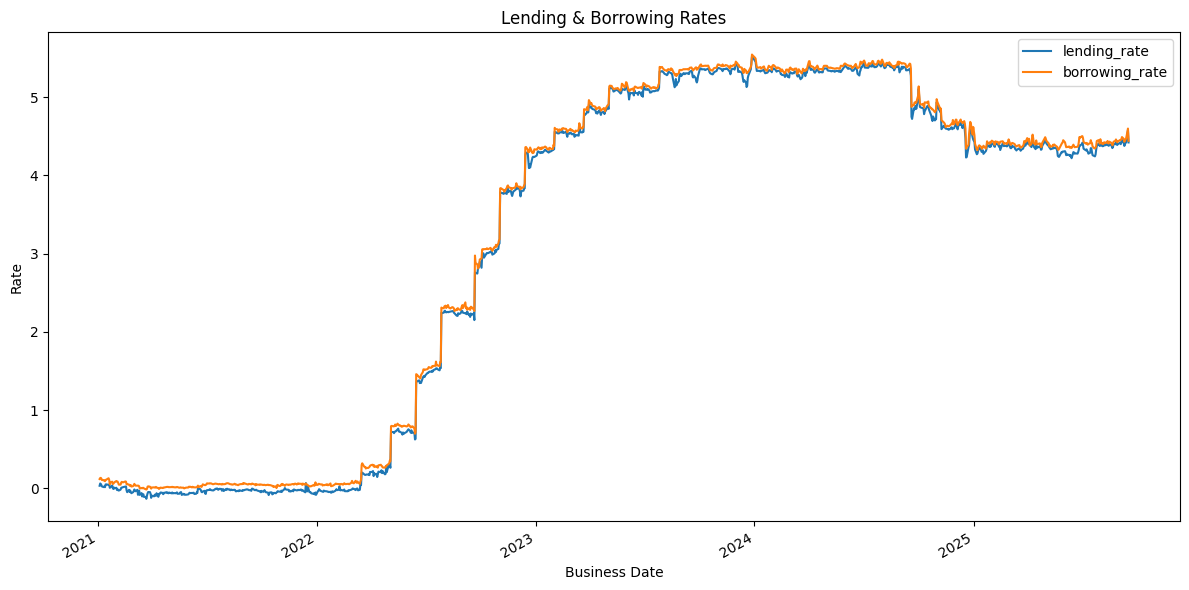

In [67]:
df_terms_agg = df_terms.groupby('business_date')[['lending_rate', 'borrowing_rate']].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
df_terms_agg.plot(ax=ax)
ax.set_xlabel('Business Date')
ax.set_ylabel('Rate')
ax.set_title('Lending & Borrowing Rates')
plt.tight_layout()
plt.show()

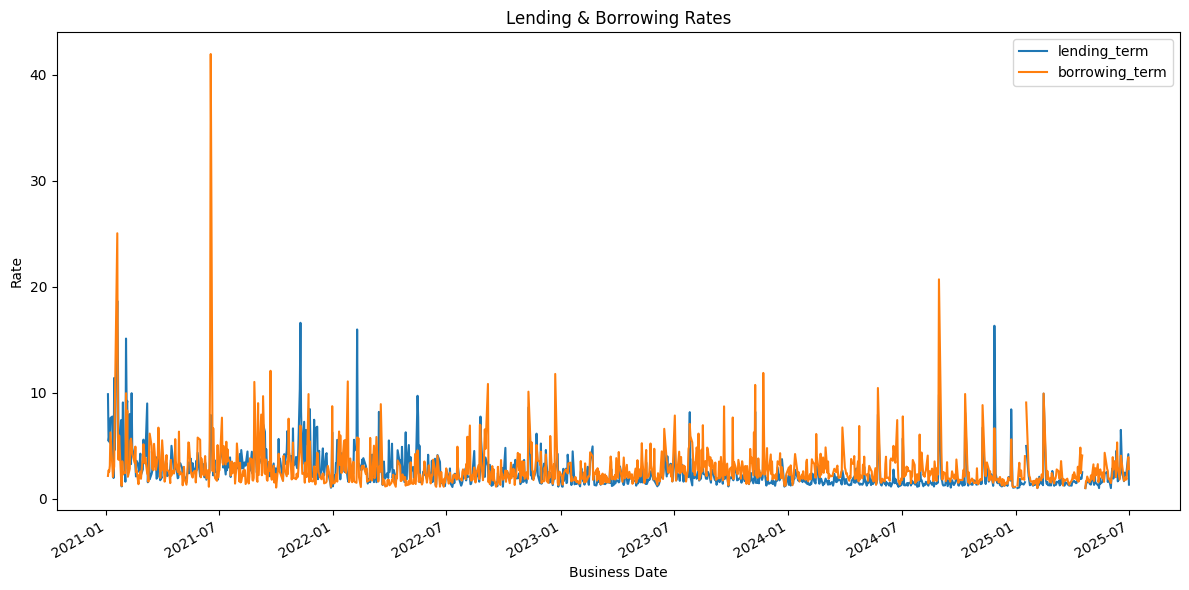

In [68]:
df_terms_agg = df_terms.groupby('business_date')[['lending_term', 'borrowing_term']].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
df_terms_agg.plot(ax=ax)
ax.set_xlabel('Business Date')
ax.set_ylabel('Rate')
ax.set_title('Lending & Borrowing Rates')
plt.tight_layout()
plt.show()

In [69]:
# Data prep
query = f"""

SELECT valdt as business_date, borrower_id as entity_id, security_isin, AVG(repo_rate) as borrowing_ON_rate
FROM xlab_ecb_prj_sftds_cb_common.hermesf_flow s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND valdt <= '2025-10-01' AND valdt >= '2021-01-01'
AND central_clearing = 'non-cleared'
AND borrower_country_residence = 'KY'
AND s_borrower.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
AND contractual_maturity <= 1
GROUP BY valdt, borrower_id, security_isin
ORDER BY valdt, borrower_id, security_isin

"""

df_borrowing_overnight = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_6756\3037316460.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing_overnight = pd.read_sql_query(query, cnxn)


In [70]:
# Data prep
query = f"""

SELECT valdt as business_date, lender_id as entity_id, security_isin, AVG(repo_rate) as lending_ON_rate
FROM xlab_ecb_prj_sftds_cb_common.hermesf_flow s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND valdt <= '2025-10-01' AND valdt >= '2021-01-01'
AND central_clearing = 'non-cleared'
AND lender_country_residence = 'KY'
AND s_lender.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
AND contractual_maturity <= 1
GROUP BY valdt, lender_id, security_isin
ORDER BY valdt, lender_id, security_isin

"""

df_lending_overnight = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_6756\390221194.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending_overnight = pd.read_sql_query(query, cnxn)


In [71]:
df_overnight = df_borrowing_overnight.merge(df_lending_overnight, on = ['business_date', 'entity_id', 'security_isin'], how = 'outer')

In [72]:
df_overnight['business_date'] = pd.to_datetime(df_overnight['business_date'])

In [73]:
df = df_terms.merge(df_overnight, on = ['business_date', 'entity_id', 'security_isin'], how = 'left')

In [76]:
df.to_csv('USD_terms.csv')